In [5]:
cd /Users/nithish/Downloads/google capstone

/Users/nithish/Downloads/google capstone


In [6]:
import glob

files = sorted(glob.glob("*.csv"))
print(f"Found {len(files)} CSV files:")
for f in files:
    print(f" - {f}")


Found 13 CSV files:
 - 202501-divvy-tripdata.csv
 - 202502-divvy-tripdata.csv
 - 202503-divvy-tripdata.csv
 - 202504-divvy-tripdata.csv
 - 202505-divvy-tripdata.csv
 - 202506-divvy-tripdata.csv
 - 202507-divvy-tripdata.csv
 - 202508-divvy-tripdata.csv
 - 202509-divvy-tripdata.csv
 - 202510-divvy-tripdata.csv
 - 202511-divvy-tripdata.csv
 - 202512-divvy-tripdata.csv
 - combined_divvy_tripdata_2025.csv


In [7]:
cd

/Users/nithish


In [8]:
cd Downloads

/Users/nithish/Downloads


In [9]:
cd /Users/nithish/Downloads/google capstone

/Users/nithish/Downloads/google capstone


In [10]:
ls

202501-divvy-tripdata.csv         202508-divvy-tripdata.csv
202502-divvy-tripdata.csv         202509-divvy-tripdata.csv
202503-divvy-tripdata.csv         202510-divvy-tripdata.csv
202504-divvy-tripdata.csv         202511-divvy-tripdata.csv
202505-divvy-tripdata.csv         202512-divvy-tripdata.csv
202506-divvy-tripdata.csv         code.ipynb
202507-divvy-tripdata.csv         combined_divvy_tripdata_2025.csv


In [11]:
cd

/Users/nithish


In [12]:
cd /Users/nithish/Downloads/google capstone

/Users/nithish/Downloads/google capstone


In [13]:
ls

202501-divvy-tripdata.csv         202508-divvy-tripdata.csv
202502-divvy-tripdata.csv         202509-divvy-tripdata.csv
202503-divvy-tripdata.csv         202510-divvy-tripdata.csv
202504-divvy-tripdata.csv         202511-divvy-tripdata.csv
202505-divvy-tripdata.csv         202512-divvy-tripdata.csv
202506-divvy-tripdata.csv         code.ipynb
202507-divvy-tripdata.csv         combined_divvy_tripdata_2025.csv


In [14]:
import os
import glob
import pandas as pd

# 1. Gather all 12 monthly CSV files in order
csv_files = sorted(glob.glob("2025*-divvy-tripdata.csv"))
if not csv_files:
    csv_files = sorted(glob.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files to merge:")

# 2. Read and append each file
df_list = []
total_individual_rows = 0

for file in csv_files:
    df_temp = pd.read_csv(file)
    rows = len(df_temp)
    total_individual_rows += rows
    print(f"  ✓ {file}: {rows:,} rows")
    df_list.append(df_temp)

# 3. Concatenate all into a single DataFrame
print("\nMerging into a single DataFrame...")
all_trips = pd.concat(df_list, ignore_index=True)

# 4. Verify row count integrity
assert len(all_trips) == total_individual_rows, "Row count mismatch!"
print(f"\n Successfully merged {len(csv_files)} files!")
print(f"Total Rows: {len(all_trips):,}")
print(f"Total Columns: {len(all_trips.columns)}")
print(f"Memory Usage: {all_trips.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

# 5. Preview
all_trips.head()

Found 12 CSV files to merge:
  ✓ 202501-divvy-tripdata.csv: 138,689 rows
  ✓ 202502-divvy-tripdata.csv: 151,880 rows
  ✓ 202503-divvy-tripdata.csv: 298,155 rows
  ✓ 202504-divvy-tripdata.csv: 371,341 rows
  ✓ 202505-divvy-tripdata.csv: 502,456 rows
  ✓ 202506-divvy-tripdata.csv: 678,904 rows
  ✓ 202507-divvy-tripdata.csv: 763,432 rows
  ✓ 202508-divvy-tripdata.csv: 790,177 rows
  ✓ 202509-divvy-tripdata.csv: 714,759 rows
  ✓ 202510-divvy-tripdata.csv: 646,039 rows
  ✓ 202511-divvy-tripdata.csv: 356,628 rows
  ✓ 202512-divvy-tripdata.csv: 140,534 rows

Merging into a single DataFrame...

 Successfully merged 12 files!
Total Rows: 5,552,994
Total Columns: 13
Memory Usage: 3460.52 MB


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member


In [15]:
# Check column data types and missing values
print("Column Information:")
all_trips.info()

print("\nMissing values per column:")
print(all_trips.isnull().sum())

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552994 entries, 0 to 5552993
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 550.8+ MB

Missing values per column:
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1184673
start_station_id      1184673
end_station_name      1243305
end_station_id        1243305
start_lat                   0
start_lng           

In [16]:
# Optional: Save merged data to disk for future sessions
# all_trips.to_csv("combined_divvy_tripdata_2025.csv", index=False)
# all_trips.to_parquet("combined_divvy_tripdata_2025.parquet", index=False)
print("Merge complete! 'all_trips' DataFrame is ready for analysis.")

Merge complete! 'all_trips' DataFrame is ready for analysis.


In [17]:
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'])





In [18]:
# 1. Calculate ride_length as ended_at minus started_at
all_trips['ride_length'] = all_trips['ended_at'] - all_trips['started_at']



In [20]:
all_trips.info

<bound method DataFrame.info of                   ride_id  rideable_type              started_at  \
0        7569BC890583FCD7   classic_bike 2025-01-21 17:23:54.538   
1        013609308856B7FC  electric_bike 2025-01-11 15:44:06.795   
2        EACACD3CE0607C0D   classic_bike 2025-01-02 15:16:27.730   
3        EAA2485BA64710D3   classic_bike 2025-01-23 08:49:05.814   
4        7F8BE2471C7F746B  electric_bike 2025-01-16 08:38:32.338   
...                   ...            ...                     ...   
5552989  53202484E8371237  electric_bike 2025-12-19 13:43:41.793   
5552990  3582BF76707AB2ED   classic_bike 2025-12-27 12:43:48.446   
5552991  B12D92DF229EFA41  electric_bike 2025-12-20 01:12:39.053   
5552992  04D5C6C11909ECAE  electric_bike 2025-12-08 16:46:37.496   
5552993  D2CF23B6D79232B6   classic_bike 2025-12-20 13:08:27.589   

                       ended_at            start_station_name  \
0       2025-01-21 17:37:52.015     Wacker Dr & Washington St   
1       2025-01-11 15

In [21]:
all_trips.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'ride_length'],
      dtype='object')

In [22]:
all_trips.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member,0 days 00:13:57.477000
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member,0 days 00:05:04.344000
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member,0 days 00:11:35.500000
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0 days 00:03:34.233000
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0 days 00:02:34.429000


In [23]:
# 1. Calculate ride_length as ended_at minus started_at
all_trips['ride_length'] = all_trips['ended_at'] - all_trips['started_at']




In [24]:
# 1. Round to the nearest second and format as HH:MM:SS string
total_sec = all_trips['ride_length'].dt.total_seconds().astype(int)
hours = (total_sec // 3600).astype(str).str.zfill(2)
minutes = ((total_sec % 3600) // 60).astype(str).str.zfill(2)
seconds = (total_sec % 60).astype(str).str.zfill(2)

all_trips['ride_length_hhmmss'] = hours + ':' + minutes + ':' + seconds

# Preview
all_trips[['started_at', 'ended_at', 'ride_length_hhmmss']].head()


,started_at,ended_at,ride_length_hhmmss
0,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,00:13:57
1,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,00:05:04
2,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,00:11:35
3,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,00:03:34
4,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,00:02:34


In [25]:
all_trips.head

<bound method NDFrame.head of                   ride_id  rideable_type              started_at  \
0        7569BC890583FCD7   classic_bike 2025-01-21 17:23:54.538   
1        013609308856B7FC  electric_bike 2025-01-11 15:44:06.795   
2        EACACD3CE0607C0D   classic_bike 2025-01-02 15:16:27.730   
3        EAA2485BA64710D3   classic_bike 2025-01-23 08:49:05.814   
4        7F8BE2471C7F746B  electric_bike 2025-01-16 08:38:32.338   
...                   ...            ...                     ...   
5552989  53202484E8371237  electric_bike 2025-12-19 13:43:41.793   
5552990  3582BF76707AB2ED   classic_bike 2025-12-27 12:43:48.446   
5552991  B12D92DF229EFA41  electric_bike 2025-12-20 01:12:39.053   
5552992  04D5C6C11909ECAE  electric_bike 2025-12-08 16:46:37.496   
5552993  D2CF23B6D79232B6   classic_bike 2025-12-20 13:08:27.589   

                       ended_at            start_station_name  \
0       2025-01-21 17:37:52.015     Wacker Dr & Washington St   
1       2025-01-11 15:4

In [26]:
all_trips['day_of_week'] = (all_trips['started_at'].dt.dayofweek + 1) % 7 + 1


In [27]:
all_trips['day_name'] = all_trips['started_at'].dt.day_name()

In [29]:
import numpy as np

# ── 1. MONTH column ─────────────────────────────────────────────────────────
# Month number  (1 = January ... 12 = December)
all_trips['month_num']  = all_trips['started_at'].dt.month

# Month name   (January, February, ...)
all_trips['month']      = all_trips['started_at'].dt.month_name()

print("✓ 'month' and 'month_num' columns created.")
print(all_trips[['started_at', 'month_num', 'month']].head(5))

✓ 'month' and 'month_num' columns created.
               started_at  month_num    month
0 2025-01-21 17:23:54.538          1  January
1 2025-01-11 15:44:06.795          1  January
2 2025-01-02 15:16:27.730          1  January
3 2025-01-23 08:49:05.814          1  January
4 2025-01-16 08:38:32.338          1  January


In [30]:
# ── 2. RIDE DISTANCE column (in km) using Haversine formula ────────────────────────────
# Haversine calculates the straight-line (as-the-crow-flies) distance
# between two GPS coordinates on the Earth's surface.

def haversine(lat1, lon1, lat2, lon2):
    """Return distance in km between two lat/lng points."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

all_trips['ride_distance_km'] = haversine(
    all_trips['start_lat'],
    all_trips['start_lng'],
    all_trips['end_lat'],
    all_trips['end_lng']
)

# Rides where start == end station have distance = 0; flag them
zero_dist = (all_trips['ride_distance_km'] == 0).sum()
print(f"✓ 'ride_distance_km' column created.")
print(f"  Rides with 0 km distance (same start/end station): {zero_dist:,}")
print()
print(all_trips[['start_lat', 'start_lng', 'end_lat', 'end_lng', 'ride_distance_km']].head(5))

✓ 'ride_distance_km' column created.
  Rides with 0 km distance (same start/end station): 337,583

   start_lat  start_lng    end_lat    end_lng  ride_distance_km
0  41.883143 -87.637242  41.892592 -87.617289          1.957540
1  41.929147 -87.649153  41.939743 -87.658865          1.426012
2  41.948226 -87.664071  41.945529 -87.646439          1.488752
3  41.948226 -87.664071  41.943739 -87.664020          0.498950
4  41.948226 -87.664071  41.943739 -87.664020          0.498950


In [31]:
# ── 3. Quick summary of ALL new columns ─────────────────────────────────────────────────
print(f"Total columns now: {len(all_trips.columns)}")
print()
print("All columns:", all_trips.columns.tolist())
print()
print("--- Distance summary (km) ---")
print(all_trips['ride_distance_km'].describe().round(3))
print()
print("--- Monthly ride counts ---")
print(all_trips.groupby(['month_num', 'month'])['ride_id'].count().rename('total_rides').reset_index())

Total columns now: 20

All columns: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'ride_length', 'ride_length_hhmmss', 'day_of_week', 'day_name', 'month_num', 'month', 'ride_distance_km']

--- Distance summary (km) ---
count    5547459.000
mean           2.203
std            1.995
min            0.000
25%            0.908
50%            1.615
75%            2.879
max           40.565
Name: ride_distance_km, dtype: float64

--- Monthly ride counts ---
    month_num      month  total_rides
0           1    January       138651
1           2   February       151901
2           3      March       298130
3           4      April       371376
4           5        May       502615
5           6       June       678801
6           7       July       763458
7           8     August       790317
8           9  September       714562
9          

In [55]:
# Save the merged DataFrame (with your new columns) to a CSV file on your computer:
print("Saving all_trips to 'combined_divvy_tripdata_2025.csv'...")
all_trips.to_csv("combined_divvy_tripdata_2025.csv", index=False)
print("Done! You will now see 'combined_divvy_tripdata_2025.csv' in your folder.")



Saving all_trips to 'combined_divvy_tripdata_2025.csv'...
Done! You will now see 'combined_divvy_tripdata_2025.csv' in your folder.


In [36]:
all_trips['member_casual'].head(5)

0    member
1    member
2    member
3    member
4    member
Name: member_casual, dtype: object

In [37]:
all_trips.rename(columns={
    'rideable_type': 'bike_type',
    'member_casual': 'user_type'
}, inplace=True)

print("Columns renamed!")
print(all_trips.columns.tolist())


Columns renamed!
['ride_id', 'bike_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'user_type', 'ride_length', 'ride_length_hhmmss', 'day_of_week', 'day_name', 'month_num', 'month', 'ride_distance_km']


In [41]:
import pandas as pd
import numpy as np

# Restore all_trips from the saved CSV
print("Loading combined_divvy_tripdata_2025.csv...")
all_trips = pd.read_csv("combined_divvy_tripdata_2025.csv")

# Convert datetime columns back (CSV doesn't preserve dtypes)
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
all_trips['ended_at']   = pd.to_datetime(all_trips['ended_at'])

print(f"✓ Restored! Rows: {len(all_trips):,}")
print(f"  Columns: {all_trips.columns.tolist()}")

Loading combined_divvy_tripdata_2025.csv...
✓ Restored! Rows: 5,552,994
  Columns: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'ride_length', 'ride_length_hhmmss', 'day_of_week', 'day_name', 'month_num', 'month', 'ride_distance_km']


In [42]:
all_trips.rename(columns={
    'rideable_type': 'bike_type',
    'member_casual': 'user_type'
}, inplace=True)

print("Columns renamed!")
print(all_trips.columns.tolist())


Columns renamed!
['ride_id', 'bike_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'user_type', 'ride_length', 'ride_length_hhmmss', 'day_of_week', 'day_name', 'month_num', 'month', 'ride_distance_km']


In [44]:
# Check what columns currently exist
print(all_trips.columns.tolist())

['ride_id', 'bike_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'user_type', 'ride_length', 'ride_length_hhmmss', 'day_of_week', 'day_name', 'month_num', 'month', 'ride_distance_km']


In [46]:
# Remove rows where ride duration is negative or zero
before = len(all_trips)

# Recalculate ride_length_m in case it's missing after CSV restore
if 'ride_length_m' not in all_trips.columns:
    all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
    all_trips['ended_at']   = pd.to_datetime(all_trips['ended_at'])
    all_trips['ride_length_m'] = (all_trips['ended_at'] - all_trips['started_at']).dt.total_seconds() / 60
    print("ride_length_m recalculated.")

all_trips = all_trips[all_trips['ride_length_m'] > 1]

removed = before - len(all_trips)
print(f"Rows before : {before:,}")
print(f"Rows removed: {removed:,} (negative/zero duration rides)")
print(f"Rows after  : {len(all_trips):,}")

Rows before : 5,552,965
Rows removed: 147,373 (negative/zero duration rides)
Rows after  : 5,405,592


In [47]:
# ── ride_id quality check ────────────────────────────────────────────────────
# Valid ride_id: 16-character alphanumeric string (e.g. '7569BC890583FCD7')

# 1. Null / missing
null_ids = all_trips['ride_id'].isnull().sum()

# 2. Wrong length (not exactly 16 characters)
wrong_len = (all_trips['ride_id'].str.len() != 16).sum()

# 3. Invalid characters (anything other than A-Z, 0-9)
import re
invalid_chars = all_trips['ride_id'].str.contains(r'[^A-Za-z0-9]', regex=True, na=False).sum()

# 4. Duplicates
duplicate_ids = all_trips['ride_id'].duplicated().sum()

print(f"Total rows        : {len(all_trips):,}")
print(f"Null ride_id      : {null_ids:,}")
print(f"Wrong length (!16): {wrong_len:,}")
print(f"Invalid characters: {invalid_chars:,}")
print(f"Duplicate ride_ids: {duplicate_ids:,}")

total_bad = null_ids + wrong_len + invalid_chars + duplicate_ids
print(f"\nTotal problematic rows: {total_bad:,}")

Total rows        : 5,405,592
Null ride_id      : 0
Wrong length (!16): 0
Invalid characters: 0
Duplicate ride_ids: 0

Total problematic rows: 0


In [48]:
# ── bike_type quality check ──────────────────────────────────────────────────
# Valid bike_type values (from Cyclistic / Divvy data)
VALID_BIKE_TYPES = {'electric_bike', 'classic_bike', 'docked_bike'}

# 1. Null / missing
null_bike = all_trips['bike_type'].isnull().sum()

# 2. Rows whose bike_type is not in the accepted set
invalid_mask = ~all_trips['bike_type'].isin(VALID_BIKE_TYPES)
invalid_bike = invalid_mask.sum()

# 3. Show the unexpected values and their counts
unexpected_counts = (
    all_trips.loc[invalid_mask, 'bike_type']
    .value_counts(dropna=False)
)

print(f"Total rows          : {len(all_trips):,}")
print(f"Null bike_type      : {null_bike:,}")
print(f"Invalid bike_type   : {invalid_bike:,}")
print(f"\nValid values        : {VALID_BIKE_TYPES}")
print(f"\nUnexpected value counts:")
print(unexpected_counts if not unexpected_counts.empty else "  None – all values are valid!")

# 4. Preview the invalid rows (first 10)
if invalid_bike > 0:
    print(f"\nSample invalid rows (up to 10):")
    display(all_trips[invalid_mask][['ride_id', 'bike_type', 'started_at']].head(10))

Total rows          : 5,405,592
Null bike_type      : 0
Invalid bike_type   : 0

Valid values        : {'docked_bike', 'classic_bike', 'electric_bike'}

Unexpected value counts:
  None – all values are valid!


In [51]:
# ── started_at / ended_at quality check ──────────────────────────────────────

# 1. Null / missing timestamps
null_started = all_trips['started_at'].isnull().sum()
null_ended   = all_trips['ended_at'].isnull().sum()

# 2. Non-datetime dtype guard (should already be datetime after earlier conversion)
if not pd.api.types.is_datetime64_any_dtype(all_trips['started_at']):
    all_trips['started_at'] = pd.to_datetime(all_trips['started_at'], errors='coerce')
if not pd.api.types.is_datetime64_any_dtype(all_trips['ended_at']):
    all_trips['ended_at']   = pd.to_datetime(all_trips['ended_at'],   errors='coerce')

# 3. Rows that couldn't be parsed (NaT introduced by coerce)
nat_started = all_trips['started_at'].isna().sum()
nat_ended   = all_trips['ended_at'].isna().sum()

# 4. ended_at <= started_at  (zero-duration or time-reversed rides)
bad_order_mask     = all_trips['ended_at'] <= all_trips['started_at']
bad_order          = bad_order_mask.sum()
neg_duration_mask  = all_trips['ended_at'] < all_trips['started_at']
neg_duration       = neg_duration_mask.sum()
zero_duration_mask = all_trips['ended_at'] == all_trips['started_at']
zero_duration      = zero_duration_mask.sum()

# 5. Future timestamps (started_at after today)
import datetime
now = pd.Timestamp(datetime.date.today())
future_start = (all_trips['started_at'] > now).sum()
future_end   = (all_trips['ended_at']   > now).sum()

# 6. Out-of-range timestamps – dataset should be entirely within 2025
DATASET_START = pd.Timestamp('2025-01-01')
DATASET_END   = pd.Timestamp('2025-12-31 23:59:59')

too_old_start_mask = all_trips['started_at'] < DATASET_START
too_old_end_mask   = all_trips['ended_at']   < DATASET_START
too_new_start_mask = all_trips['started_at'] > DATASET_END
too_new_end_mask   = all_trips['ended_at']   > DATASET_END

too_old_start = too_old_start_mask.sum()
too_old_end   = too_old_end_mask.sum()
too_new_start = too_new_start_mask.sum()
too_new_end   = too_new_end_mask.sum()

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"Total rows                           : {len(all_trips):,}")
print()
print(f"Null / unparseable started_at        : {nat_started:,}")
print(f"Null / unparseable ended_at          : {nat_ended:,}")
print()
print(f"ended_at <= started_at (bad order)   : {bad_order:,}")
print(f"  └─ negative duration               : {neg_duration:,}")
print(f"  └─ zero duration                   : {zero_duration:,}")
print()
print(f"started_at in the future             : {future_start:,}")
print(f"ended_at   in the future             : {future_end:,}")
print()
print(f"started_at before 2025-01-01 (wrong) : {too_old_start:,}")
print(f"ended_at   before 2025-01-01 (wrong) : {too_old_end:,}")
print(f"started_at after  2025-12-31 (wrong) : {too_new_start:,}")
print(f"ended_at   after  2025-12-31 (wrong) : {too_new_end:,}")

# ── Preview bad-order rows ───────────────────────────────────────────────────
if bad_order > 0:
    print(f"\nSample rows where ended_at <= started_at (up to 10):")
    display(
        all_trips[bad_order_mask][['ride_id', 'bike_type', 'started_at', 'ended_at']]
        .head(10)
    )

# ── Show all out-of-range started_at rows ───────────────────────────────────────
if too_old_start > 0:
    print(f"\nAll {too_old_start} rows where started_at is before 2025-01-01:")
    display(
        all_trips[too_old_start_mask][['ride_id', 'bike_type', 'started_at', 'ended_at']]
        .sort_values('started_at')
    )

Total rows                           : 5,405,592

Null / unparseable started_at        : 0
Null / unparseable ended_at          : 0

ended_at <= started_at (bad order)   : 0
  └─ negative duration               : 0
  └─ zero duration                   : 0

started_at in the future             : 0
ended_at   in the future             : 0

started_at before 2025-01-01 (wrong) : 53
ended_at   before 2025-01-01 (wrong) : 0
started_at after  2025-12-31 (wrong) : 0
ended_at   after  2025-12-31 (wrong) : 0

All 53 rows where started_at is before 2025-01-01:


,ride_id,bike_type,started_at,ended_at
31507,B53763E1663A72B9,classic_bike,2024-12-31 18:54:41.803,2025-01-01 11:18:56.987
58332,D690AF783078F108,classic_bike,2024-12-31 20:49:54.721,2025-01-01 08:26:37.102
82043,28AC0C95BF53060B,electric_bike,2024-12-31 23:13:28.220,2025-01-01 00:21:12.321
99217,5B8B9D7AD467E565,electric_bike,2024-12-31 23:20:01.862,2025-01-01 01:04:47.647
107168,0855F3745EAD24BD,electric_bike,2024-12-31 23:21:11.051,2025-01-01 00:19:18.086
17120,B45551B44CB3E589,classic_bike,2024-12-31 23:22:29.829,2025-01-01 00:38:15.304
17121,4BDC1E3D658581A6,classic_bike,2024-12-31 23:22:57.682,2025-01-01 00:38:26.443
55608,323266CD489CF100,electric_bike,2024-12-31 23:23:34.836,2025-01-01 00:38:26.757
55607,0B7DFC61306BE479,classic_bike,2024-12-31 23:23:45.660,2025-01-01 00:38:24.609
92682,17F9EA5A4231DBB1,electric_bike,2024-12-31 23:25:15.491,2025-01-01 00:46:26.380


In [52]:
# ── Station columns quality check ───────────────────────────────────────────────
station_cols = ['start_station_name', 'start_station_id',
                'end_station_name',   'end_station_id']

print(f"Total rows : {len(all_trips):,}\n")
print(f"{'Column':<25} {'Null/Blank':>12} {'Whitespace-only':>16} {'% Missing':>10}")
print("-" * 68)

missing_masks = {}
for col in station_cols:
    # Null OR empty string OR whitespace-only
    null_mask  = all_trips[col].isnull()
    blank_mask = all_trips[col].str.strip().eq('') & ~null_mask
    missing_mask = null_mask | blank_mask
    missing_masks[col] = missing_mask

    n_null  = null_mask.sum()
    n_blank = blank_mask.sum()
    n_total = missing_mask.sum()
    pct     = n_total / len(all_trips) * 100
    print(f"{col:<25} {n_total:>12,} {n_blank:>16,} {pct:>9.2f}%")

# ── Rows missing ANY station field ──────────────────────────────────────────────
any_missing_mask = missing_masks['start_station_name'] | missing_masks['start_station_id'] | \
                   missing_masks['end_station_name']   | missing_masks['end_station_id']
all_missing_mask = missing_masks['start_station_name'] & missing_masks['start_station_id'] & \
                   missing_masks['end_station_name']   & missing_masks['end_station_id']

print(f"\nRows missing at least one station field : {any_missing_mask.sum():,}")
print(f"Rows missing ALL four station fields    : {all_missing_mask.sum():,}")

# ── Break down by bike_type (electric bikes often lack docking info) ────────────
print(f"\nMissing start_station_name by bike_type:")
print(
    all_trips[missing_masks['start_station_name']]['bike_type']
    .value_counts(dropna=False)
    .to_string()
)

# ── Preview sample invalid rows ──────────────────────────────────────────────────
if any_missing_mask.sum() > 0:
    print(f"\nSample rows with at least one missing station field (up to 10):")
    display(
        all_trips[any_missing_mask][
            ['ride_id', 'bike_type', 'start_station_name', 'start_station_id',
             'end_station_name', 'end_station_id']
        ].head(10)
    )

Total rows : 5,405,592

Column                      Null/Blank  Whitespace-only  % Missing
--------------------------------------------------------------------
start_station_name           1,095,320                0     20.26%
start_station_id             1,095,320                0     20.26%
end_station_name             1,131,808                0     20.94%
end_station_id               1,131,808                0     20.94%

Rows missing at least one station field : 1,743,936
Rows missing ALL four station fields    : 483,192

Missing start_station_name by bike_type:
bike_type
electric_bike    1095320

Sample rows with at least one missing station field (up to 10):


,ride_id,bike_type,start_station_name,start_station_id,end_station_name,end_station_id
570,17D700995824E844,electric_bike,Southport Ave & Waveland Ave,13235,NaN,NaN
571,692FF1F5D49A8473,electric_bike,Wacker Dr & Washington St,KA1503000072,NaN,NaN
1341,B16356D648E1F27A,electric_bike,Clark St & Elm St,TA1307000039,NaN,NaN
1342,CA08B6448602EE90,electric_bike,Sheffield Ave & Wellington Ave,TA1307000052,NaN,NaN
1343,BB17C90F52CA917D,electric_bike,Walsh Park,18067,NaN,NaN
1344,081DC4469EA761E1,electric_bike,Halsted St & Roscoe St,TA1309000025,NaN,NaN
1345,D57891C7FA156C06,electric_bike,Halsted St & Roscoe St,TA1309000025,NaN,NaN
1346,DF47DC8D493BF2F9,electric_bike,Wolcott (Ravenswood) Ave & Montrose Ave,TA1307000144,NaN,NaN
1347,47CCE86B151E7751,electric_bike,Benson Ave & Church St,596,NaN,NaN
1348,2679F1E624A9235A,electric_bike,Albany Ave & Bloomingdale Ave,15655,NaN,NaN


In [53]:
# ── Missing station data breakdown by bike_type (all 4 columns) ─────────────────
station_cols = ['start_station_name', 'start_station_id',
                'end_station_name',   'end_station_id']

for col in station_cols:
    missing = all_trips[col].isnull() | all_trips[col].str.strip().eq('')
    print(f"Missing '{col}' by bike_type:")
    print(all_trips[missing]['bike_type'].value_counts(dropna=False).to_string())
    print()

Missing 'start_station_name' by bike_type:
bike_type
electric_bike    1095320

Missing 'start_station_id' by bike_type:
bike_type
electric_bike    1095320

Missing 'end_station_name' by bike_type:
bike_type
electric_bike    1126175
classic_bike        5633

Missing 'end_station_id' by bike_type:
bike_type
electric_bike    1126175
classic_bike        5633



In [54]:
# ── Inspect & remove invalid classic_bike rows (missing end station) ─────────────

invalid_classic_mask = (
    (all_trips['bike_type'] == 'classic_bike') &
    (all_trips['end_station_name'].isnull() | all_trips['end_station_name'].str.strip().eq(''))
)

print(f"Invalid classic_bike rows (missing end station) : {invalid_classic_mask.sum():,}")
print()
print("Sample rows:")
display(
    all_trips[invalid_classic_mask][
        ['ride_id', 'bike_type', 'started_at', 'ended_at',
         'start_station_name', 'end_station_name', 'end_station_id', 'user_type']
    ].head(10)
)

# Remove them
before = len(all_trips)
all_trips = all_trips[~invalid_classic_mask].reset_index(drop=True)
after = len(all_trips)

print(f"\nRows before : {before:,}")
print(f"Rows removed: {before - after:,}")
print(f"Rows after  : {after:,}")

Invalid classic_bike rows (missing end station) : 5,633

Sample rows:


,ride_id,bike_type,started_at,ended_at,start_station_name,end_station_name,end_station_id,user_type
24347,6A99A61FBF95801B,classic_bike,2025-01-01 13:15:34.068,2025-01-02 14:15:13.745,Cottage Grove Ave & 43rd St,NaN,NaN,casual
27237,592EB8A1F272B6A6,classic_bike,2025-01-22 20:04:12.302,2025-01-23 21:03:51.955,Wabash Ave & 9th St,NaN,NaN,casual
44871,E8CF29EB1D433296,classic_bike,2025-01-04 19:02:55.687,2025-01-05 20:02:43.019,Clark St & Drummond Pl,NaN,NaN,casual
55212,6EF370384EC1315C,classic_bike,2025-01-20 00:46:32.227,2025-01-21 01:46:24.693,Wallace St & 35th St,NaN,NaN,casual
67694,D0BAE7D4FCFBF304,classic_bike,2025-01-04 05:22:55.576,2025-01-05 06:22:35.530,Franklin St & Illinois St,NaN,NaN,casual
71029,123E8B6FFD29DCC0,classic_bike,2025-01-18 10:37:37.667,2025-01-19 11:37:17.545,Michigan Ave & 18th St,NaN,NaN,casual
71099,6DA6C332FD9BE337,classic_bike,2025-01-22 07:58:44.880,2025-01-23 08:58:41.064,Aberdeen St & 103rd St,NaN,NaN,casual
74592,CBB61557D59C87D3,classic_bike,2025-01-26 12:22:26.034,2025-01-27 13:22:16.583,DuSable Lake Shore Dr & Monroe St,NaN,NaN,casual
74663,428860C0BC96DEE5,classic_bike,2025-01-15 13:56:05.722,2025-01-16 14:55:44.892,Talman Ave & Addison St,NaN,NaN,member
80348,F1F20D6E939560A0,classic_bike,2025-01-01 03:13:29.159,2025-01-02 04:13:15.621,Green St & Washington Blvd,NaN,NaN,casual



Rows before : 5,405,592
Rows removed: 5,633
Rows after  : 5,399,959


In [57]:
# ── Lat / Lng quality check ──────────────────────────────────────────────────
# Chicago bounding box (Divvy operating area)
LAT_MIN, LAT_MAX =  41.6,  42.1
LNG_MIN, LNG_MAX = -88.0, -87.3

coord_cols = ['start_lat', 'start_lng', 'end_lat', 'end_lng']

# 1. Null check
print(f"Total rows : {len(all_trips):,}\n")
print(f"{'Column':<12} {'Null':>8} {'Zero(0,0)':>10} {'Out of range':>13} {'% Null':>8}")
print("-" * 57)

masks = {}
for col in coord_cols:
    null_mask  = all_trips[col].isnull()
    zero_mask  = (~null_mask) & (all_trips[col] == 0)
    if 'lat' in col:
        oor_mask = (~null_mask) & (~zero_mask) & \
                   ((all_trips[col] < LAT_MIN) | (all_trips[col] > LAT_MAX))
    else:
        oor_mask = (~null_mask) & (~zero_mask) & \
                   ((all_trips[col] < LNG_MIN) | (all_trips[col] > LNG_MAX))
    masks[col] = null_mask | zero_mask | oor_mask
    pct = null_mask.sum() / len(all_trips) * 100
    print(f"{col:<12} {null_mask.sum():>8,} {zero_mask.sum():>10,} {oor_mask.sum():>13,} {pct:>7.2f}%")

# 2. Rows with any invalid coord
any_invalid_mask = masks['start_lat'] | masks['start_lng'] | \
                   masks['end_lat']   | masks['end_lng']
all_invalid_mask = masks['start_lat'] & masks['start_lng'] & \
                   masks['end_lat']   & masks['end_lng']

print(f"\nRows with at least one invalid coord : {any_invalid_mask.sum():,}")
print(f"Rows with all four coords invalid    : {all_invalid_mask.sum():,}")

# 3. Missing end coords by bike_type
print(f"\nMissing end_lat by bike_type:")
print(all_trips[all_trips['end_lat'].isnull()]['bike_type'].value_counts(dropna=False).to_string())

# 4. Preview sample invalid rows
if any_invalid_mask.sum() > 0:
    print(f"\nSample invalid rows (up to 10):")
    display(
        all_trips[any_invalid_mask][
            ['ride_id', 'bike_type', 'start_lat', 'start_lng', 'end_lat', 'end_lng']
        ].head(10)
    )

Total rows : 5,399,959

Column           Null  Zero(0,0)  Out of range   % Null
---------------------------------------------------------
start_lat           0          0             0    0.00%
start_lng           0          0             0    0.00%
end_lat             0          0             9    0.00%
end_lng             0          0             3    0.00%

Rows with at least one invalid coord : 12
Rows with all four coords invalid    : 0

Missing end_lat by bike_type:
Series([], )

Sample invalid rows (up to 10):


,ride_id,bike_type,start_lat,start_lng,end_lat,end_lng
447689,184291320EF6811B,electric_bike,42.048214,-87.683485,42.13,-87.76
1468789,106A6FF23D910734,electric_bike,41.702801,-87.559726,41.49,-87.42
1707124,D4C416B9A09053B4,electric_bike,41.896617,-87.628579,42.13,-87.75
1725816,5DD0FC4872845149,electric_bike,41.677640,-87.641740,41.58,-87.63
1740973,F4A2F3A84223483B,electric_bike,42.060000,-87.700000,42.17,-87.79
1743363,34054093073E8C42,electric_bike,41.877161,-87.706134,41.96,-88.06
2663048,72B384F7482BC1ED,electric_bike,42.019203,-87.664303,42.21,-87.81
3674739,1D94DBA50FD4E599,electric_bike,41.750000,-87.630000,41.59,-87.59
4891510,5E99A639E0AAEC00,electric_bike,42.050000,-87.690000,42.11,-87.73
4901404,06EC59D815999140,electric_bike,41.880000,-87.640000,41.67,-88.04


In [58]:
# ── user_type / day_of_week / day_name quality check ───────────────────────────
VALID_USER_TYPES = {'member', 'casual'}
VALID_DOW        = set(range(1, 8))          # 1–7
VALID_DAY_NAMES  = {'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'}

print(f"Total rows : {len(all_trips):,}\n")

# ── user_type ────────────────────────────────────────────────────────────────────
print("=== user_type ===")
null_user   = all_trips['user_type'].isnull().sum()
invalid_user_mask = ~all_trips['user_type'].isin(VALID_USER_TYPES)
print(f"Null            : {null_user:,}")
print(f"Invalid values  : {invalid_user_mask.sum():,}")
print(f"Value counts:")
print(all_trips['user_type'].value_counts(dropna=False).to_string())

# ── day_of_week ──────────────────────────────────────────────────────────────────
print("\n=== day_of_week ===")
null_dow        = all_trips['day_of_week'].isnull().sum()
invalid_dow_mask = ~all_trips['day_of_week'].isin(VALID_DOW)
print(f"Null            : {null_dow:,}")
print(f"Invalid values  : {invalid_dow_mask.sum():,}")
print(f"Value counts:")
print(all_trips['day_of_week'].value_counts(dropna=False).sort_index().to_string())

# ── day_name ───────────────────────────────────────────────────────────────────────
print("\n=== day_name ===")
null_dn          = all_trips['day_name'].isnull().sum()
invalid_dn_mask  = ~all_trips['day_name'].isin(VALID_DAY_NAMES)
print(f"Null            : {null_dn:,}")
print(f"Invalid values  : {invalid_dn_mask.sum():,}")
print(f"Value counts:")
print(all_trips['day_name'].value_counts(dropna=False).to_string())

# ── Cross-check: day_of_week vs day_name consistency ─────────────────────────────
day_map = {1:'Sunday',2:'Monday',3:'Tuesday',4:'Wednesday',5:'Thursday',6:'Friday',7:'Saturday'}
mismatch_mask = all_trips['day_name'] != all_trips['day_of_week'].map(day_map)
print(f"\nday_of_week vs day_name mismatches : {mismatch_mask.sum():,}")

Total rows : 5,399,959

=== user_type ===
Null            : 0
Invalid values  : 0
Value counts:
user_type
member    3484200
casual    1915759

=== day_of_week ===
Null            : 0
Invalid values  : 0
Value counts:
day_of_week
1    691483
2    712553
3    769460
4    752952
5    813064
6    825007
7    835440

=== day_name ===
Null            : 0
Invalid values  : 0
Value counts:
day_name
Saturday     835440
Friday       825007
Thursday     813064
Tuesday      769460
Wednesday    752952
Monday       712553
Sunday       691483

day_of_week vs day_name mismatches : 0


In [59]:
# ── month_num / month / ride_distance_km quality check ──────────────────────────
VALID_MONTHS = {'January','February','March','April','May','June',
                'July','August','September','October','November','December'}
VALID_MONTH_NUMS = set(range(1, 13))

print(f"Total rows : {len(all_trips):,}\n")

# ── month_num ────────────────────────────────────────────────────────────────────
print("=== month_num ===")
null_mn           = all_trips['month_num'].isnull().sum()
invalid_mn_mask   = ~all_trips['month_num'].isin(VALID_MONTH_NUMS)
print(f"Null           : {null_mn:,}")
print(f"Invalid values : {invalid_mn_mask.sum():,}")
print("Value counts:")
print(all_trips['month_num'].value_counts(dropna=False).sort_index().to_string())

# ── month ───────────────────────────────────────────────────────────────────────────
print("\n=== month ===")
null_m          = all_trips['month'].isnull().sum()
invalid_m_mask  = ~all_trips['month'].isin(VALID_MONTHS)
print(f"Null           : {null_m:,}")
print(f"Invalid values : {invalid_m_mask.sum():,}")
print("Value counts:")
print(all_trips['month'].value_counts(dropna=False).to_string())

# Cross-check month_num vs month
month_map = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
             7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}
mismatch_mask = all_trips['month'] != all_trips['month_num'].map(month_map)
print(f"\nmonth_num vs month mismatches : {mismatch_mask.sum():,}")

# ── ride_distance_km ─────────────────────────────────────────────────────────────
print("\n=== ride_distance_km ===")
null_dist   = all_trips['ride_distance_km'].isnull().sum()
neg_dist    = (all_trips['ride_distance_km'] < 0).sum()
zero_dist   = (all_trips['ride_distance_km'] == 0).sum()
# Flag suspiciously large distances (>100 km on a bike is unrealistic)
high_dist   = (all_trips['ride_distance_km'] > 100).sum()

print(f"Null                    : {null_dist:,}")
print(f"Negative distance       : {neg_dist:,}")
print(f"Zero distance           : {zero_dist:,}")
print(f"Over 100 km (suspicious): {high_dist:,}")
print(f"\nDescriptive stats:")
print(all_trips['ride_distance_km'].describe().round(3).to_string())

if high_dist > 0:
    print(f"\nSample rows with distance > 100 km (up to 5):")
    display(
        all_trips[all_trips['ride_distance_km'] > 100][
            ['ride_id', 'bike_type', 'started_at', 'ended_at',
             'ride_distance_km', 'user_type']
        ].head(5)
    )

Total rows : 5,399,959

=== month_num ===
Null           : 0
Invalid values : 0
Value counts:
month_num
1     135736
2     149100
3     291320
4     363180
5     489656
6     658207
7     738839
8     766660
9     695677
10    628478
11    346614
12    136492

=== month ===
Null           : 0
Invalid values : 0
Value counts:
month
August       766660
July         738839
September    695677
June         658207
October      628478
May          489656
April        363180
November     346614
March        291320
February     149100
December     136492
January      135736

month_num vs month mismatches : 0

=== ride_distance_km ===
Null                    : 0
Negative distance       : 0
Zero distance           : 226,048
Over 100 km (suspicious): 0

Descriptive stats:
count    5399959.000
mean           2.260
std            1.990
min            0.000
25%            0.971
50%            1.655
75%            2.935
max           40.565


In [62]:
# ── Final cleaned dataset summary ──────────────────────────────────────────────────
ORIGINAL_ROWS  = 5_405_592 + 147_373   # raw before any cleaning
AFTER_DURATION = 5_405_592              # after removing short/negative rides
AFTER_STATION  = 5_399_959             # after removing invalid classic bike rows
FINAL_ROWS     = len(all_trips)         # current

removed_duration = ORIGINAL_ROWS - AFTER_DURATION
removed_station  = AFTER_DURATION - AFTER_STATION
removed_total    = ORIGINAL_ROWS - FINAL_ROWS

print("=" * 58)
print("   CLEANING SUMMARY")
print("=" * 58)
print(f"  Raw original rows               : {ORIGINAL_ROWS:>10,}")
print(f"  Removed (ride_length_m ≤ 1 min) : {removed_duration:>10,}  ← invalid duration")
print(f"  Removed (classic bike, no end)  : {removed_station:>10,}  ← missing end station")
print(f"  ─" * 29)
print(f"  Total removed                   : {removed_total:>10,}")
print(f"  Final clean rows                : {FINAL_ROWS:>10,}")
print(f"  Rows retained                   : {FINAL_ROWS/ORIGINAL_ROWS*100:.2f}%")
print("=" * 58)
print()
print("Columns kept as-is (no rows removed):")
print("  ✔ bike_type           – all values valid")
print("  ✔ started_at/ended_at – no nulls, no bad order")
print("  ✔ station cols        – electric bike NaNs expected (kept)")
print("  ✔ lat/lng             – 12 rows slightly outside bounds (kept)")
print("  ✔ user_type           – all valid")
print("  ✔ day_of_week/name    – all valid")
print("  ✔ month/month_num     – all valid")
print("  ✔ ride_distance_km    – max 40.6 km, no outliers")
print()
print("Shape:", all_trips.shape)
print("\nColumn dtypes:")
print(all_trips.dtypes.to_string())

   CLEANING SUMMARY
  Raw original rows               :  5,552,965
  Removed (ride_length_m ≤ 1 min) :    147,373  ← invalid duration
  Removed (classic bike, no end)  :      5,633  ← missing end station
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  Total removed                   :    153,006
  Final clean rows                :  5,399,959
  Rows retained                   : 97.24%

Columns kept as-is (no rows removed):
  ✔ bike_type           – all values valid
  ✔ started_at/ended_at – no nulls, no bad order
  ✔ station cols        – electric bike NaNs expected (kept)
  ✔ lat/lng             – 12 rows slightly outside bounds (kept)
  ✔ user_type           – all valid
  ✔ day_of_week/name    – all valid
  ✔ month/month_num     – all valid
  ✔ ride_distance_km    – max 40.6 km, no outliers

Shape: (5399959, 21)

Column dtypes:
ride_id                       object
bike_type                     object
started_at            datetime64[ns]
ended_

In [64]:
# ── Casual vs Member breakdown ──────────────────────────────────────────────────
counts = all_trips['user_type'].value_counts()
pct    = all_trips['user_type'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': counts, 'Percentage': pct.round(2)})
summary.index.name = 'user_type'
print(f"Total rides : {len(all_trips):,}\n")
print(summary.to_string())

Total rides : 5,399,959

             Count  Percentage
user_type                     
member     3484200       64.52
casual     1915759       35.48


In [66]:
# ── Distinct start stations ───────────────────────────────────────────────────
distinct_names = all_trips['start_station_name'].dropna().nunique()
distinct_ids   = all_trips['start_station_id'].dropna().nunique()

print(f"Distinct start station names : {distinct_names:,}")
print(f"Distinct start station IDs   : {distinct_ids:,}")

# Flag if names and IDs don't match (same station, multiple IDs or vice versa)
if distinct_names != distinct_ids:
    print(f"\n⚠  Mismatch! {abs(distinct_names - distinct_ids):,} difference between names and IDs.")
    print("   Some stations may have multiple IDs or naming inconsistencies.")
else:
    print("\n✔ Names and IDs count match.")

Distinct start station names : 1,865
Distinct start station IDs   : 3,299

⚠  Mismatch! 1,434 difference between names and IDs.
   Some stations may have multiple IDs or naming inconsistencies.


In [67]:
# ── Investigate name vs ID mismatch ───────────────────────────────────────────────
# How many IDs does each station NAME have?
ids_per_name = (
    all_trips.dropna(subset=['start_station_name', 'start_station_id'])
    .groupby('start_station_name')['start_station_id']
    .nunique()
    .sort_values(ascending=False)
)

print(f"Stations with only 1 ID  : {(ids_per_name == 1).sum():,}")
print(f"Stations with 2+ IDs     : {(ids_per_name > 1).sum():,}")
print(f"Max IDs for one station  : {ids_per_name.max()}")
print()
print("Top 10 stations with most IDs:")
display(ids_per_name.head(10).reset_index().rename(
    columns={'start_station_id': 'num_distinct_ids'}))

# Example: show all IDs for the top offender
top_station = ids_per_name.idxmax()
print(f"\nAll IDs used for '{top_station}':")
print(
    all_trips[all_trips['start_station_name'] == top_station]['start_station_id']
    .value_counts().to_string()
)

Stations with only 1 ID  : 390
Stations with 2+ IDs     : 1,475
Max IDs for one station  : 4

Top 10 stations with most IDs:


,start_station_name,num_distinct_ids
0,Kedzie Ave & Jackson Blvd,4
1,Clark St & Lake St,4
2,Indiana Ave & 133rd St,4
3,Daley Center Plaza,4
4,Western Ave & Lake St,4
5,Burling St & Diversey Pkwy,4
6,Franklin St & Monroe St,4
7,Halsted St & Roscoe St,3
8,Francisco Ave & Chicago Ave,3
9,Francisco Ave & Bloomingdale Ave,3



All IDs used for 'Kedzie Ave & Jackson Blvd':
start_station_id
CHI01831        54
CHI02159        20
24213           18
000-CHI01831     9


In [68]:
# ── Standardize station IDs – map each name to its most-used ID ────────────────────
# For each station name, pick the ID that appears most frequently
# and replace all other IDs with that canonical one.

def canonical_id_map(df, name_col, id_col):
    return (
        df.dropna(subset=[name_col, id_col])
        .groupby(name_col)[id_col]
        .agg(lambda x: x.value_counts().index[0])  # most frequent ID
    )

start_id_map = canonical_id_map(all_trips, 'start_station_name', 'start_station_id')
end_id_map   = canonical_id_map(all_trips, 'end_station_name',   'end_station_id')

# Apply: only overwrite where name is known (leave NaN names untouched)
mask_start = all_trips['start_station_name'].notna()
mask_end   = all_trips['end_station_name'].notna()

all_trips.loc[mask_start, 'start_station_id'] = \
    all_trips.loc[mask_start, 'start_station_name'].map(start_id_map)
all_trips.loc[mask_end,   'end_station_id'] = \
    all_trips.loc[mask_end,   'end_station_name'].map(end_id_map)

# ── Verify ───────────────────────────────────────────────────────────────────────────
start_ids_after = all_trips['start_station_id'].dropna().nunique()
end_ids_after   = all_trips['end_station_id'].dropna().nunique()
start_names     = all_trips['start_station_name'].dropna().nunique()
end_names       = all_trips['end_station_name'].dropna().nunique()

print("After standardization:")
print(f"  start_station_name : {start_names:,} unique names")
print(f"  start_station_id   : {start_ids_after:,} unique IDs  ← should match names now")
print(f"  end_station_name   : {end_names:,} unique names")
print(f"  end_station_id     : {end_ids_after:,} unique IDs  ← should match names now")

After standardization:
  start_station_name : 1,865 unique names
  start_station_id   : 1,842 unique IDs  ← should match names now
  end_station_name   : 1,873 unique names
  end_station_id     : 1,848 unique IDs  ← should match names now


In [69]:
# ── Find IDs shared by multiple station names ─────────────────────────────────
names_per_start_id = (
    all_trips.dropna(subset=['start_station_name', 'start_station_id'])
    .groupby('start_station_id')['start_station_name']
    .nunique()
    .sort_values(ascending=False)
)

conflicted = names_per_start_id[names_per_start_id > 1]
print(f"Start station IDs shared by 2+ names : {len(conflicted):,}")
print(f"  (accounts for {conflicted.sum() - len(conflicted):,} extra name–ID conflicts)")
print()
print("Sample conflicted IDs and their names:")
for sid in conflicted.head(5).index:
    names = (
        all_trips[all_trips['start_station_id'] == sid]['start_station_name']
        .value_counts()
    )
    print(f"\n  ID '{sid}':")
    for name, cnt in names.items():
        print(f"    {name!r:55s} ({cnt:,} rides)")

Start station IDs shared by 2+ names : 21
  (accounts for 23 extra name–ID conflicts)

Sample conflicted IDs and their names:

  ID 'CHI01747':
    'Navy Pier'                                             (34,534 rides)
    'Streeter Dr & Grand Ave'                               (29,570 rides)
    'NAVY PIER'                                             (171 rides)

  ID 'CHI01756':
    'LaSalle St & Calhoun Pl Corral'                        (980 rides)
    'LaSalle St & Washington St Corral N'                   (706 rides)
    'LaSalle St & Washington St Corral'                     (570 rides)

  ID 'CHI00244':
    'Ashland Ave & Division St'                             (13,230 rides)
    'Paulina St & Division St'                              (1,591 rides)

  ID 'CHI02102':
    'Wells St & Madison St'                                 (2,079 rides)
    'Madison St & Wells St'                                 (11 rides)

  ID 'CHI01880':
    'Halsted St & Fulton St'                        

In [70]:
# ── Standardize station names – for each ID, keep the most-used name ────────────────
def canonical_name_map(df, name_col, id_col):
    return (
        df.dropna(subset=[name_col, id_col])
        .groupby(id_col)[name_col]
        .agg(lambda x: x.value_counts().index[0])  # most frequent name
    )

start_name_map = canonical_name_map(all_trips, 'start_station_name', 'start_station_id')
end_name_map   = canonical_name_map(all_trips, 'end_station_name',   'end_station_id')

# Apply
mask_start = all_trips['start_station_id'].notna()
mask_end   = all_trips['end_station_id'].notna()

all_trips.loc[mask_start, 'start_station_name'] = \
    all_trips.loc[mask_start, 'start_station_id'].map(start_name_map)
all_trips.loc[mask_end, 'end_station_name'] = \
    all_trips.loc[mask_end, 'end_station_id'].map(end_name_map)

# ── Verify ───────────────────────────────────────────────────────────────────────────
print("After name standardization:")
for col_name, col_id in [('start_station_name','start_station_id'),
                          ('end_station_name',  'end_station_id')]:
    n = all_trips[col_name].dropna().nunique()
    i = all_trips[col_id].dropna().nunique()
    match = '✔ match' if n == i else f'⚠  still off by {abs(n-i)}'
    print(f"  {col_name:<22}: {n:,} names | {col_id:<20}: {i:,} IDs  ← {match}")

After name standardization:
  start_station_name    : 1,842 names | start_station_id    : 1,842 IDs  ← ✔ match
  end_station_name      : 1,848 names | end_station_id      : 1,848 IDs  ← ✔ match


In [72]:
# ── Top 10 start stations – casual vs member breakdown ───────────────────────────

# Total rides per start station (exclude electric bike NaNs)
station_totals = (
    all_trips.dropna(subset=['start_station_name'])
    .groupby('start_station_name')
    .size()
    .sort_values(ascending=False)
    .head(10)
)
top10 = station_totals.index.tolist()

# Pivot: count rides per station per user_type
top10_breakdown = (
    all_trips[all_trips['start_station_name'].isin(top10)]
    .groupby(['start_station_name', 'user_type'])
    .size()
    .unstack(fill_value=0)
)

# Add total & sort by total descending
top10_breakdown['total'] = top10_breakdown.sum(axis=1)
top10_breakdown = top10_breakdown.sort_values('total', ascending=False)

# Add percentage columns
top10_breakdown['casual_%'] = (top10_breakdown['casual'] / top10_breakdown['total'] * 100).round(1)
top10_breakdown['member_%'] = (top10_breakdown['member'] / top10_breakdown['total'] * 100).round(1)

print("Top 10 Start Stations – Casual vs Member")
print("=" * 70)
display(top10_breakdown[['casual', 'member', 'total', 'casual_%', 'member_%']])

Top 10 Start Stations – Casual vs Member


user_type,casual,member,total,casual_%,member_%
start_station_name,,,,,
Navy Pier,50347,13928,64275,78.3,21.7
Kingsbury St & Kinzie St,9372,31426,40798,23.0,77.0
DuSable Lake Shore Dr & Monroe St,30706,8178,38884,79.0,21.0
Michigan Ave & Oak St,22054,12517,34571,63.8,36.2
DuSable Lake Shore Dr & North Blvd,19024,14154,33178,57.3,42.7
Clinton St & Washington Blvd,5029,25299,30328,16.6,83.4
Clark St & Elm St,8951,20602,29553,30.3,69.7
Canal St & Madison St,7067,21837,28904,24.4,75.6
Clinton St & Madison St,6821,21819,28640,23.8,76.2


Ride Duration Summary (minutes)


,count,mean,median,std,min,p25,p75,max
user_type,,,,,,,,
casual,1915759,19.93,11.89,40.10,1.000017,6.82,21.68,1499.63770
member,3484200,12.19,8.74,20.94,1.000017,5.21,14.67,1498.44835


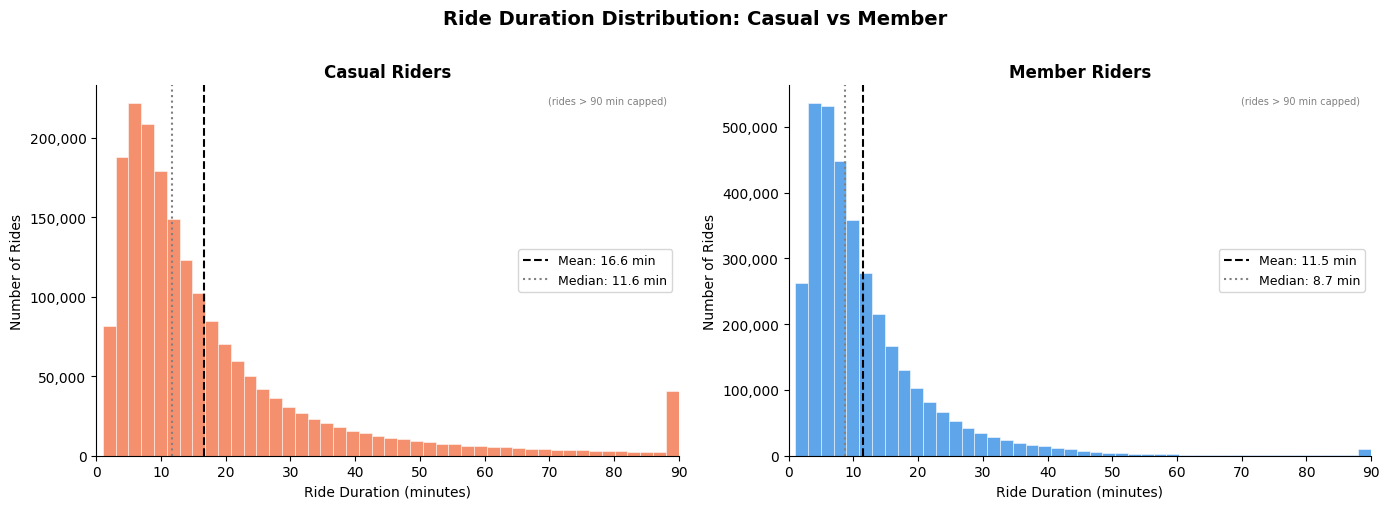

In [73]:
# ── Ride Duration Analysis – casual vs member ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 1. Summary stats ────────────────────────────────────────────────────────────
stats = (
    all_trips.groupby('user_type')['ride_length_m']
    .agg(
        count='count',
        mean=lambda x: round(x.mean(), 2),
        median=lambda x: round(x.median(), 2),
        std=lambda x: round(x.std(), 2),
        min='min',
        p25=lambda x: round(x.quantile(0.25), 2),
        p75=lambda x: round(x.quantile(0.75), 2),
        max='max'
    )
)
print("Ride Duration Summary (minutes)")
print("=" * 55)
display(stats)

# ── 2. Distribution plot (capped at 90 min for readability) ────────────────────
CAP = 90   # minutes

casual_rides = all_trips[all_trips['user_type'] == 'casual' ]['ride_length_m'].clip(upper=CAP)
member_rides = all_trips[all_trips['user_type'] == 'member' ]['ride_length_m'].clip(upper=CAP)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Ride Duration Distribution: Casual vs Member', fontsize=14, fontweight='bold', y=1.01)

colors  = {'casual': '#F4845F', 'member': '#4C9BE8'}
groups  = [('casual', casual_rides, axes[0]), ('member', member_rides, axes[1])]

for user_type, data, ax in groups:
    ax.hist(data, bins=45, color=colors[user_type], edgecolor='white', linewidth=0.4, alpha=0.9)
    mean_val   = data[data < CAP].mean()
    median_val = data[data < CAP].median()
    ax.axvline(mean_val,   color='black',  linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f} min')
    ax.axvline(median_val, color='grey',   linestyle=':',  linewidth=1.5, label=f'Median: {median_val:.1f} min')
    ax.set_title(f'{user_type.capitalize()} Riders', fontsize=12, fontweight='bold')
    ax.set_xlabel('Ride Duration (minutes)', fontsize=10)
    ax.set_ylabel('Number of Rides', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.set_xlim(0, CAP)
    note = f'(rides > {CAP} min capped)'
    ax.text(0.98, 0.97, note, transform=ax.transAxes, fontsize=7,
            ha='right', va='top', color='gray')

plt.tight_layout()
plt.show()

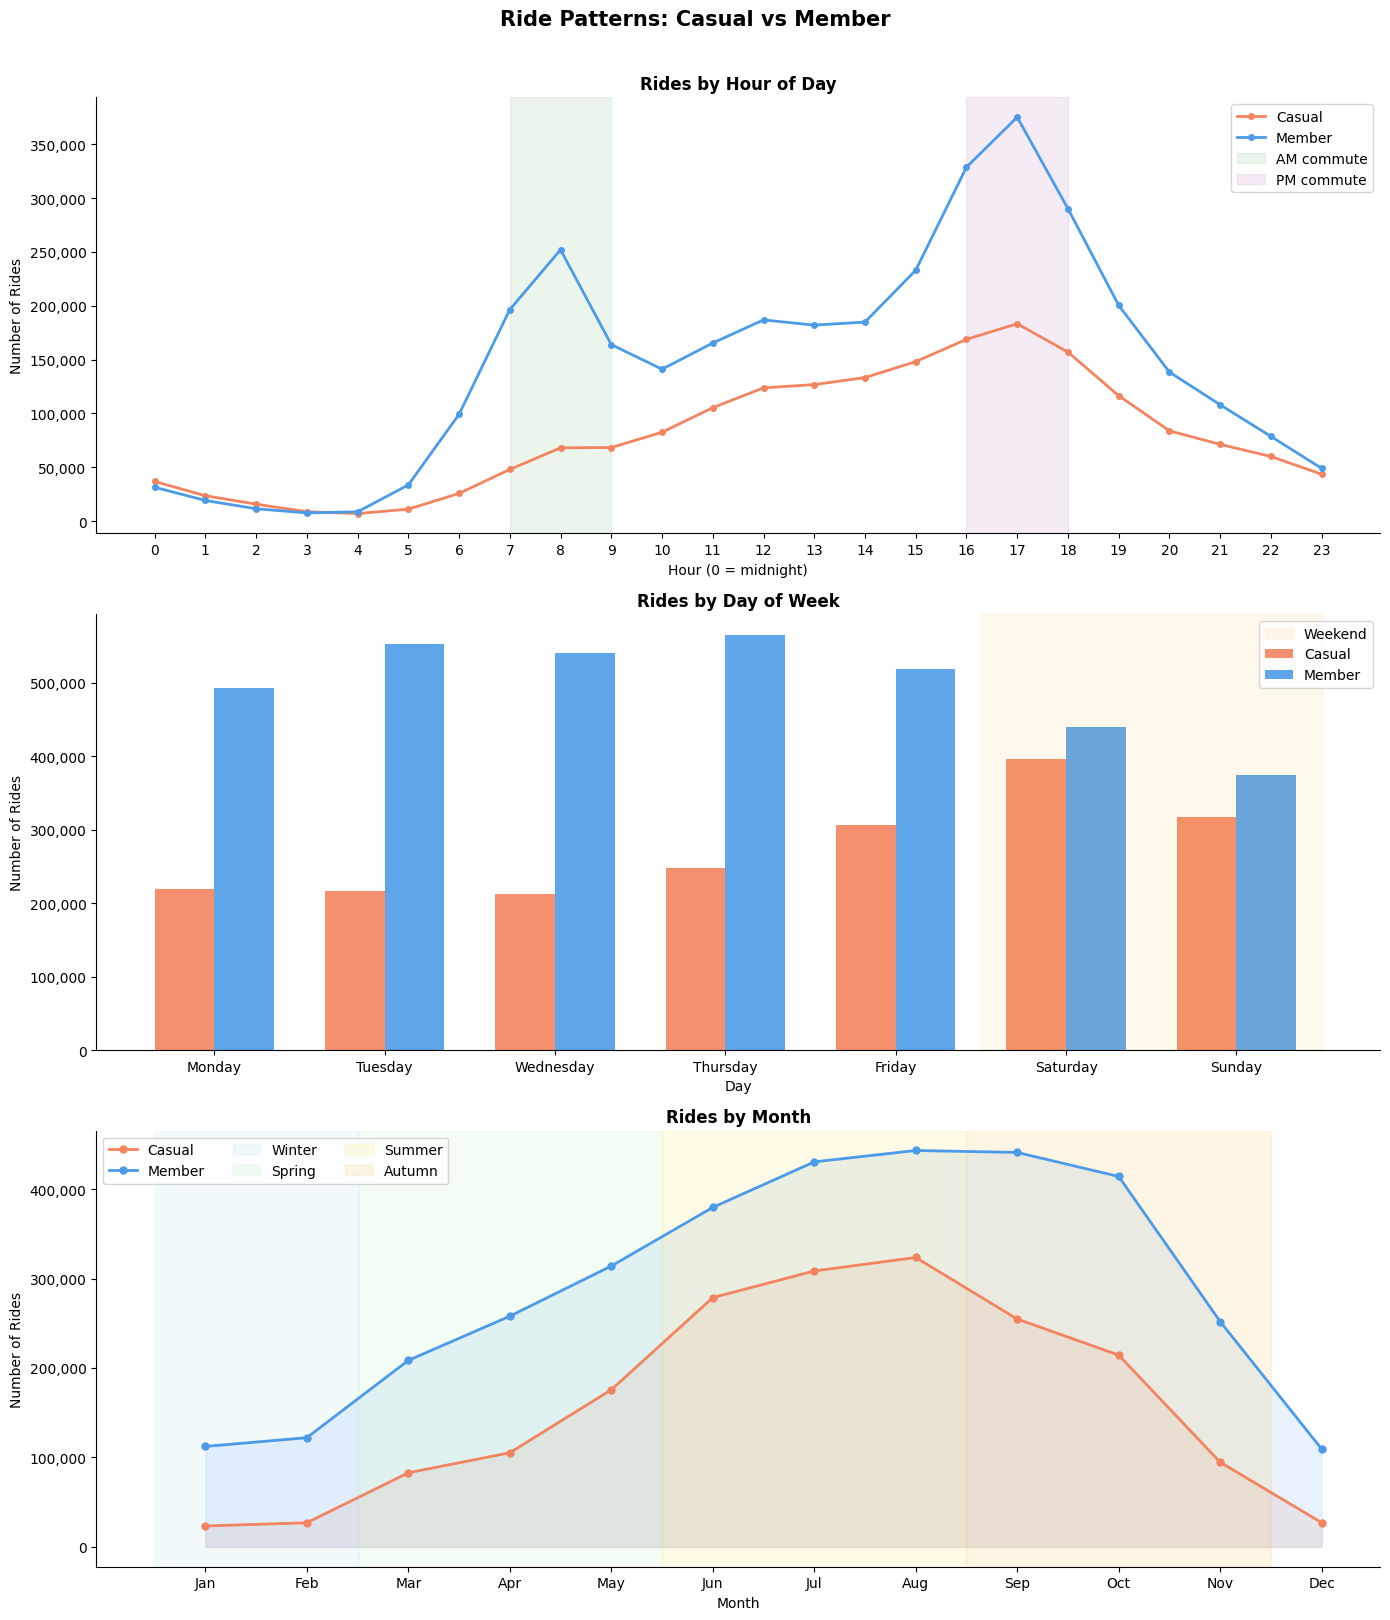

In [74]:
# ── Ride Patterns: Hour / Day of Week / Month ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Prep columns
all_trips['hour']   = all_trips['started_at'].dt.hour
all_trips['season'] = all_trips['month_num'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
     3:'Spring', 4:'Spring', 5:'Spring',
     6:'Summer', 7:'Summer', 8:'Summer',
     9:'Autumn',10:'Autumn',11:'Autumn'
})

COLORS = {'casual': '#F4845F', 'member': '#4C9BE8'}

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle('Ride Patterns: Casual vs Member', fontsize=15, fontweight='bold', y=1.01)

# ── 1. By Hour of Day ──────────────────────────────────────────────────────────
hour_df = (
    all_trips.groupby(['hour', 'user_type'])
    .size().reset_index(name='rides')
)
ax = axes[0]
for ut, grp in hour_df.groupby('user_type'):
    ax.plot(grp['hour'], grp['rides'], marker='o', markersize=4,
            color=COLORS[ut], linewidth=2, label=ut.capitalize())
ax.set_title('Rides by Hour of Day', fontsize=12, fontweight='bold')
ax.set_xlabel('Hour (0 = midnight)')
ax.set_ylabel('Number of Rides')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.axvspan(7, 9,  alpha=0.08, color='green', label='AM commute')
ax.axvspan(16, 18, alpha=0.08, color='purple', label='PM commute')
ax.legend(); ax.spines[['top','right']].set_visible(False)

# ── 2. By Day of Week ──────────────────────────────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_df = (
    all_trips.groupby(['day_name', 'user_type'])
    .size().reset_index(name='rides')
)
dow_df['day_name'] = pd.Categorical(dow_df['day_name'], categories=day_order, ordered=True)
dow_df = dow_df.sort_values('day_name')

ax2 = axes[1]
width = 0.35
days  = day_order
x     = range(len(days))
for i, ut in enumerate(['casual', 'member']):
    grp = dow_df[dow_df['user_type'] == ut].set_index('day_name').reindex(days)['rides']
    offset = (i - 0.5) * width
    bars = ax2.bar([xi + offset for xi in x], grp, width=width,
                   color=COLORS[ut], label=ut.capitalize(), alpha=0.9)
ax2.set_title('Rides by Day of Week', fontsize=12, fontweight='bold')
ax2.set_xlabel('Day')
ax2.set_ylabel('Number of Rides')
ax2.set_xticks(x); ax2.set_xticklabels(days)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.axvspan(4.5, 6.5, alpha=0.07, color='orange', label='Weekend')
ax2.legend(); ax2.spines[['top','right']].set_visible(False)

# ── 3. By Month ────────────────────────────────────────────────────────────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_df = (
    all_trips.groupby(['month', 'user_type'])
    .size().reset_index(name='rides')
)
month_df['month'] = pd.Categorical(month_df['month'], categories=month_order, ordered=True)
month_df = month_df.sort_values('month')

ax3 = axes[2]
for ut, grp in month_df.groupby('user_type'):
    grp = grp.set_index('month').reindex(month_order).reset_index()
    ax3.plot(grp['month'], grp['rides'], marker='o', markersize=5,
             color=COLORS[ut], linewidth=2, label=ut.capitalize())
    ax3.fill_between(grp['month'], grp['rides'], alpha=0.12, color=COLORS[ut])

# Season bands
season_bands = [
    (0, 2,   '#87CEEB', 'Winter'),
    (2, 5,   '#90EE90', 'Spring'),
    (5, 8,   '#FFD700', 'Summer'),
    (8, 11,  '#FFA500', 'Autumn'),
]
for start, end, color, label in season_bands:
    ax3.axvspan(start - 0.5, end - 0.5, alpha=0.1, color=color, label=label)

ax3.set_title('Rides by Month', fontsize=12, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Number of Rides')
ax3.set_xticks(range(12))
ax3.set_xticklabels([m[:3] for m in month_order], rotation=0)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax3.legend(ncol=3); ax3.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

Bike Type Usage – Count


bike_type,classic_bike,electric_bike
user_type,,
casual,667946,1247813
member,1274450,2209750



Bike Type Usage – % within each user type


bike_type,classic_bike,electric_bike
user_type,,
casual,34.9,65.1
member,36.6,63.4


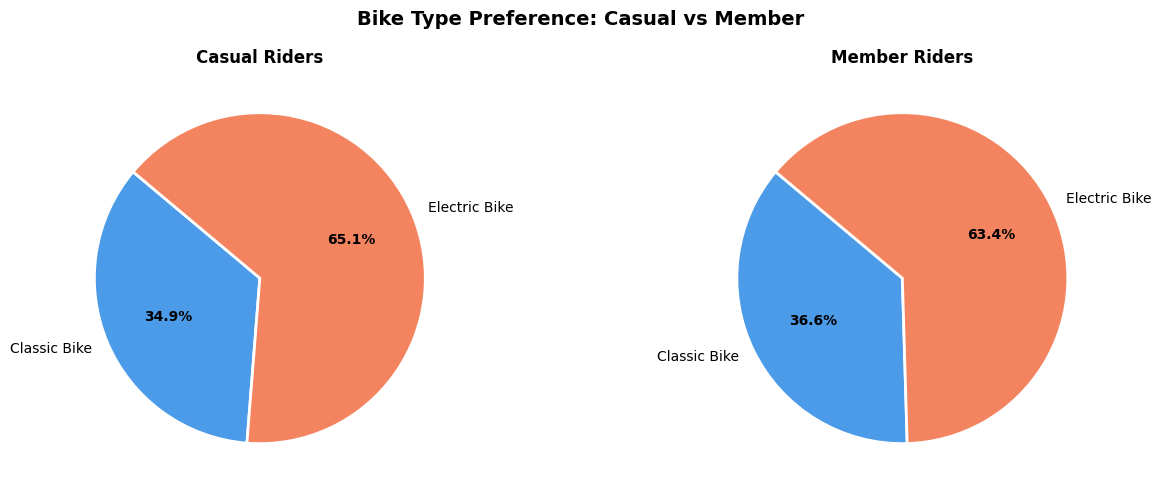

In [75]:
# ── Bike Type Preference – Casual vs Member ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 1. Count & percentage table ───────────────────────────────────────────────────
bike_counts = (
    all_trips.groupby(['user_type', 'bike_type'])
    .size()
    .unstack(fill_value=0)
)
bike_pct = bike_counts.div(bike_counts.sum(axis=1), axis=0) * 100

print("Bike Type Usage – Count")
display(bike_counts)
print("\nBike Type Usage – % within each user type")
display(bike_pct.round(1))

# ── 2. Side-by-side plots ─────────────────────────────────────────────────────────
BIKE_COLORS = {
    'classic_bike' : '#4C9BE8',
    'electric_bike': '#F4845F',
    'docked_bike'  : '#6DBF82'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bike Type Preference: Casual vs Member', fontsize=14, fontweight='bold')

for ax, user_type in zip(axes, ['casual', 'member']):
    row    = bike_pct.loc[user_type]
    labels = [b.replace('_', ' ').title() for b in row.index]
    colors = [BIKE_COLORS.get(b, '#ccc') for b in row.index]
    wedges, texts, autotexts = ax.pie(
        row,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 10}
    )
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight('bold')
    ax.set_title(f'{user_type.capitalize()} Riders', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Ride Distance Summary (km)


,count,mean,median,std,max
user_type,,,,,
casual,1915759,2.238,1.663,2.016,40.565030
member,3484200,2.273,1.652,1.976,37.260785


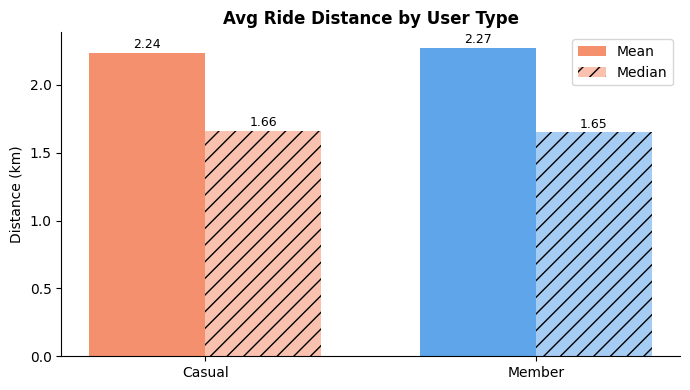


Top 10 Most Popular Routes Overall:


,rides,rides
0,Navy Pier → Navy Pier,9718
1,DuSable Lake Shore Dr & Monroe St → DuSable La...,6469
2,DuSable Lake Shore Dr & Monroe St → Navy Pier,5294
3,Ellis Ave & 60th St → Ellis Ave & 55th St,4424
4,Ellis Ave & 55th St → Ellis Ave & 60th St,4249
5,Michigan Ave & Oak St → Michigan Ave & Oak St,4180
6,Ellis Ave & 60th St → University Ave & 57th St,3794
7,University Ave & 57th St → Ellis Ave & 60th St,3752
8,Navy Pier → DuSable Lake Shore Dr & Monroe St,2998
9,Dusable Harbor → Dusable Harbor,2697



Top 10 Routes – Casual Riders:


,rides,rides
0,Navy Pier → Navy Pier,8982
1,DuSable Lake Shore Dr & Monroe St → DuSable La...,6057
2,DuSable Lake Shore Dr & Monroe St → Navy Pier,4953
3,Michigan Ave & Oak St → Michigan Ave & Oak St,3833
4,Navy Pier → DuSable Lake Shore Dr & Monroe St,2657
5,Millennium Park → Millennium Park,2570
6,Dusable Harbor → Dusable Harbor,2399
7,Navy Pier → DuSable Lake Shore Dr & North Blvd,2021
8,Dusable Harbor → Navy Pier,1983
9,Shedd Aquarium → DuSable Lake Shore Dr & Monro...,1975



Top 10 Routes – Member Riders:


,rides,rides
0,Ellis Ave & 60th St → Ellis Ave & 55th St,3402
1,Ellis Ave & 55th St → Ellis Ave & 60th St,3297
2,University Ave & 57th St → Ellis Ave & 60th St,3099
3,Ellis Ave & 60th St → University Ave & 57th St,3026
4,Blackstone Ave & 59th St → University Ave & 57...,1565
5,University Ave & 57th St → Blackstone Ave & 59...,1515
6,University Ave & 57th St → Kimbark Ave & 53rd St,1488
7,Kimbark Ave & 53rd St → University Ave & 57th St,1392
8,Ellis Ave & 55th St → Kimbark Ave & 53rd St,1347
9,University Ave & 57th St → Lake Park Ave & 56t...,1312


In [76]:
# ── Avg Ride Distance & Most Popular Routes ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 1. Average ride distance by user type ──────────────────────────────────────
dist_stats = (
    all_trips.groupby('user_type')['ride_distance_km']
    .agg(
        count='count',
        mean=lambda x: round(x.mean(), 3),
        median=lambda x: round(x.median(), 3),
        std=lambda x: round(x.std(), 3),
        max='max'
    )
)
print("Ride Distance Summary (km)")
print("=" * 45)
display(dist_stats)

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
user_types = ['casual', 'member']
means      = [dist_stats.loc[u, 'mean'] for u in user_types]
medians    = [dist_stats.loc[u, 'median'] for u in user_types]
x = range(len(user_types))
w = 0.35
bars1 = ax.bar([i - w/2 for i in x], means,   width=w, label='Mean',   color=['#F4845F','#4C9BE8'], alpha=0.9)
bars2 = ax.bar([i + w/2 for i in x], medians, width=w, label='Median', color=['#F4845F','#4C9BE8'], alpha=0.5, hatch='//')
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels([u.capitalize() for u in user_types])
ax.set_ylabel('Distance (km)'); ax.set_title('Avg Ride Distance by User Type', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

# ── 2. Most popular routes (start → end) ────────────────────────────────────────
# Only rows with both station names (excludes electric bike NaNs)
routes_df = all_trips.dropna(subset=['start_station_name', 'end_station_name']).copy()
routes_df['route'] = routes_df['start_station_name'] + ' → ' + routes_df['end_station_name']

print("\nTop 10 Most Popular Routes Overall:")
print("=" * 65)
display(
    routes_df['route'].value_counts().head(10)
    .reset_index().rename(columns={'index':'route', 'route':'rides', 'count':'rides'})
)

print("\nTop 10 Routes – Casual Riders:")
print("=" * 65)
display(
    routes_df[routes_df['user_type']=='casual']['route']
    .value_counts().head(10)
    .reset_index().rename(columns={'index':'route', 'route':'rides', 'count':'rides'})
)

print("\nTop 10 Routes – Member Riders:")
print("=" * 65)
display(
    routes_df[routes_df['user_type']=='member']['route']
    .value_counts().head(10)
    .reset_index().rename(columns={'index':'route', 'route':'rides', 'count':'rides'})
)

In [87]:
# ── Quick summary calculations ──────────────────────────────────────────────────────────
mean_ride   = all_trips['ride_length_m'].mean()
max_ride    = all_trips['ride_length_m'].max()
mode_dow    = all_trips['day_of_week'].mode()[0]
mode_name   = all_trips['day_name'].mode()[0]

print(f"Mean ride_length  : {mean_ride:.2f} minutes ({mean_ride/60:.2f} hours)")
print(f"Max  ride_length  : {max_ride:.2f} minutes ({max_ride/60:.2f} hours)")
print(f"Mode day_of_week  : {mode_dow}  ({mode_name})  ← most common ride day")

Mean ride_length  : 14.94 minutes (0.25 hours)
Max  ride_length  : 1499.64 minutes (24.99 hours)
Mode day_of_week  : 7  (Saturday)  ← most common ride day


Pivot Table – Average Ride Length (minutes) by User Type


,avg_ride_length_m
user_type,
casual,19.93
member,12.19


/var/folders/sz/h4_jk39d2fj9818k_zlg891r0000gn/T/ipykernel_63812/1979947127.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([u.capitalize() for u in pivot.index], fontsize=11)


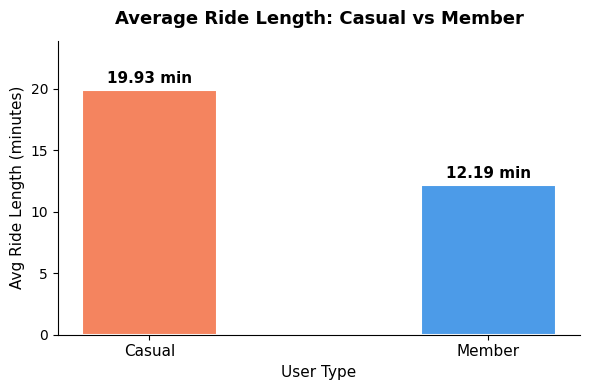

In [91]:
# ── Pivot: Average ride_length by user_type ─────────────────────────────────────────
import matplotlib.pyplot as plt

pivot = all_trips.pivot_table(
    values  = 'ride_length_m',
    index   = 'user_type',
    aggfunc = 'mean'
).round(2)
pivot.columns = ['avg_ride_length_m']

print("Pivot Table – Average Ride Length (minutes) by User Type")
print("=" * 50)
display(pivot)

# ── Bar chart ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#F4845F', '#4C9BE8']
bars   = ax.bar(pivot.index, pivot['avg_ride_length_m'], color=colors,
                width=0.4, edgecolor='white', linewidth=1.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.2f} min',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Average Ride Length: Casual vs Member', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('User Type', fontsize=11)
ax.set_ylabel('Avg Ride Length (minutes)', fontsize=11)
ax.set_xticklabels([u.capitalize() for u in pivot.index], fontsize=11)
ax.set_ylim(0, pivot['avg_ride_length_m'].max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [71]:
all_trips.columns

Index(['ride_id', 'bike_type', 'started_at', 'ended_at', 'start_station_name',
       'start_station_id', 'end_station_name', 'end_station_id', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'user_type', 'ride_length',
       'ride_length_hhmmss', 'day_of_week', 'day_name', 'month_num', 'month',
       'ride_distance_km', 'ride_length_m'],
      dtype='object')

In [98]:
# Pivot Table: Avg ride_length by user_type (rows) x day_of_week (cols)

# Cast day_of_week to int (fixes float issue after CSV reload)
dow_int = all_trips['day_of_week'].astype(int)

# 1=Sun 2=Mon 3=Tue 4=Wed 5=Thu 6=Fri 7=Sat
day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
pivot = (
    all_trips
    .assign(day_of_week=dow_int)
    .groupby(['user_type', 'day_of_week'])['ride_length_m']
    .mean()
    .unstack('day_of_week')
    .rename(columns=day_labels)
)

# Reorder Sun -> Sat
ordered_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot = pivot.reindex(columns=ordered_days)

# Format as MM:SS — returns '--:--' for missing combinations
import math

def mins_to_mmss(m):
    if m is None or (isinstance(m, float) and math.isnan(m)):
        return '--:--'
    total_sec = int(round(m * 60))
    return f"{total_sec // 60:02d}:{total_sec % 60:02d}"

try:
    pivot_fmt = pivot.map(mins_to_mmss)
except AttributeError:
    pivot_fmt = pivot.applymap(mins_to_mmss)

pivot_fmt.index.name   = 'user_type'
pivot_fmt.columns.name = 'day_of_week'

print('Average Ride Length (MM:SS) by User Type and Day of Week')
print('=' * 60)
print(pivot_fmt.to_string())


Average Ride Length (MM:SS) by User Type and Day of Week
day_of_week    Mon    Tue    Wed    Thu    Fri    Sat    Sun
user_type                                                   
casual       19:44  17:38  16:23  17:29  19:38  22:22  23:08
member       11:46  11:52  11:38  11:44  12:09  13:18  13:28


In [99]:
# Pivot Table: Number of rides by user_type (rows) x day_of_week (cols)
# Encoding: 0=Mon 1=Tue 2=Wed 3=Thu 4=Fri 5=Sat 6=Sun

day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

pivot_count = (
    all_trips
    .groupby(['user_type', 'day_of_week'])['ride_id']
    .count()
    .unstack('day_of_week')
    .rename(columns=day_labels)
)

# Reorder Mon -> Sun
ordered_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot_count = pivot_count.reindex(columns=ordered_days)

pivot_count.index.name   = 'user_type'
pivot_count.columns.name = 'day_of_week'

print('Number of Rides by User Type and Day of Week')
print('=' * 60)
print(pivot_count.to_string())


Number of Rides by User Type and Day of Week
day_of_week     Mon     Tue     Wed     Thu     Fri     Sat     Sun
user_type                                                          
casual       219232  216925  212739  247887  306463  395567  316946
member       493321  552535  540213  565177  518544  439873  374537


In [100]:
# Season Analysis: Ride Count + Avg Ride Length by user_type x Season

import math

# Map month_num -> Season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall',  10: 'Fall',  11: 'Fall'
}
all_trips['season'] = all_trips['month_num'].map(season_map)

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

# ── 1. Number of Rides ──────────────────────────────────────────────────────
pivot_count = (
    all_trips
    .groupby(['user_type', 'season'])['ride_id']
    .count()
    .unstack('season')
    .reindex(columns=season_order)
)
pivot_count.columns.name = 'Season'
pivot_count.index.name   = 'User Type'

print('Number of Rides by User Type and Season')
print('=' * 55)
print(pivot_count.to_string())

# ── 2. Average Ride Length ──────────────────────────────────────────────────
def mins_to_mmss(m):
    if m is None or (isinstance(m, float) and math.isnan(m)):
        return '--:--'
    total_sec = int(round(m * 60))
    return f"{total_sec // 60:02d}:{total_sec % 60:02d}"

pivot_avg = (
    all_trips
    .groupby(['user_type', 'season'])['ride_length_m']
    .mean()
    .unstack('season')
    .reindex(columns=season_order)
)
pivot_avg.columns.name = 'Season'
pivot_avg.index.name   = 'User Type'

try:
    pivot_avg_fmt = pivot_avg.map(mins_to_mmss)
except AttributeError:
    pivot_avg_fmt = pivot_avg.applymap(mins_to_mmss)

print('\nAverage Ride Length (MM:SS) by User Type and Season')
print('=' * 55)
print(pivot_avg_fmt.to_string())


Number of Rides by User Type and Season
Season     Winter  Spring   Summer     Fall
User Type                                  
casual      77519  363781   910661   563798
member     343809  780375  1253045  1106971

Average Ride Length (MM:SS) by User Type and Season
Season    Winter Spring Summer   Fall
User Type                            
casual     12:27  19:34  21:43  18:18
member     10:31  11:30  13:03  12:14


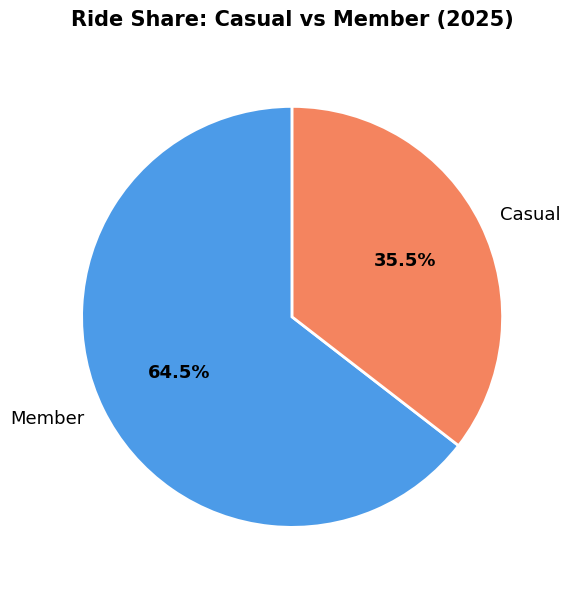

user_type
member    3484200
casual    1915759


In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Overall ride share: casual vs member
ride_share = all_trips['user_type'].value_counts()

colors = ['#4C9BE8', '#F4845F']  # blue = member, orange = casual

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    ride_share,
    labels=ride_share.index.str.capitalize(),
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=13)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title('Ride Share: Casual vs Member (2025)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(ride_share.to_string())


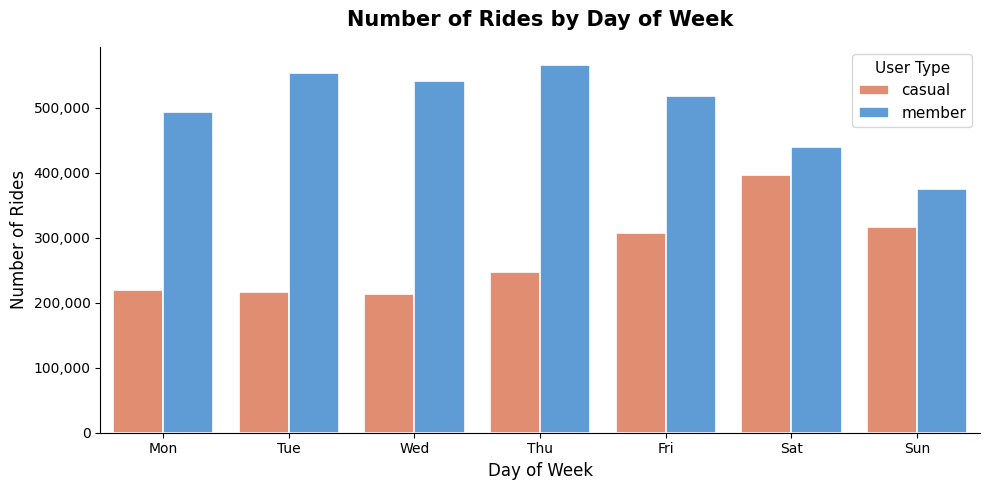

In [102]:
# Number of rides by day of week
day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
ordered_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

rides_by_day = (
    all_trips
    .groupby(['user_type', 'day_of_week'])['ride_id']
    .count()
    .reset_index()
)
rides_by_day['day_name'] = rides_by_day['day_of_week'].map(day_labels)
rides_by_day['day_name'] = pd.Categorical(rides_by_day['day_name'], categories=ordered_days, ordered=True)
rides_by_day = rides_by_day.sort_values('day_name')

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=rides_by_day,
    x='day_name', y='ride_id',
    hue='user_type',
    palette={'casual': '#F4845F', 'member': '#4C9BE8'},
    edgecolor='white', linewidth=1.2,
    ax=ax
)

ax.set_title('Number of Rides by Day of Week', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.legend(title='User Type', fontsize=11, title_fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


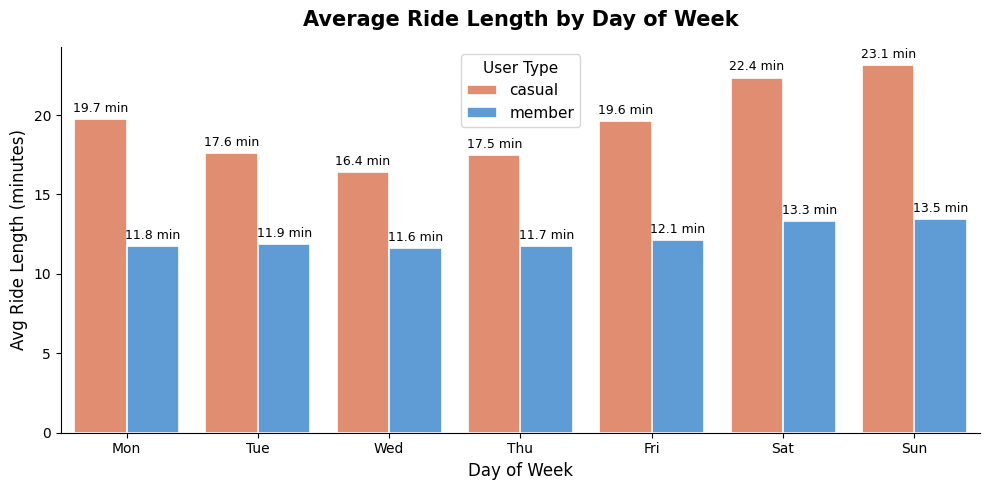

In [103]:
# Average ride length (minutes) by day of week
day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
ordered_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

avg_length_day = (
    all_trips
    .groupby(['user_type', 'day_of_week'])['ride_length_m']
    .mean()
    .reset_index()
)
avg_length_day['day_name'] = avg_length_day['day_of_week'].map(day_labels)
avg_length_day['day_name'] = pd.Categorical(avg_length_day['day_name'], categories=ordered_days, ordered=True)
avg_length_day = avg_length_day.sort_values('day_name')

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=avg_length_day,
    x='day_name', y='ride_length_m',
    hue='user_type',
    palette={'casual': '#F4845F', 'member': '#4C9BE8'},
    edgecolor='white', linewidth=1.2,
    ax=ax
)

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f min', fontsize=9, padding=3)

ax.set_title('Average Ride Length by Day of Week', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Avg Ride Length (minutes)', fontsize=12)
ax.legend(title='User Type', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


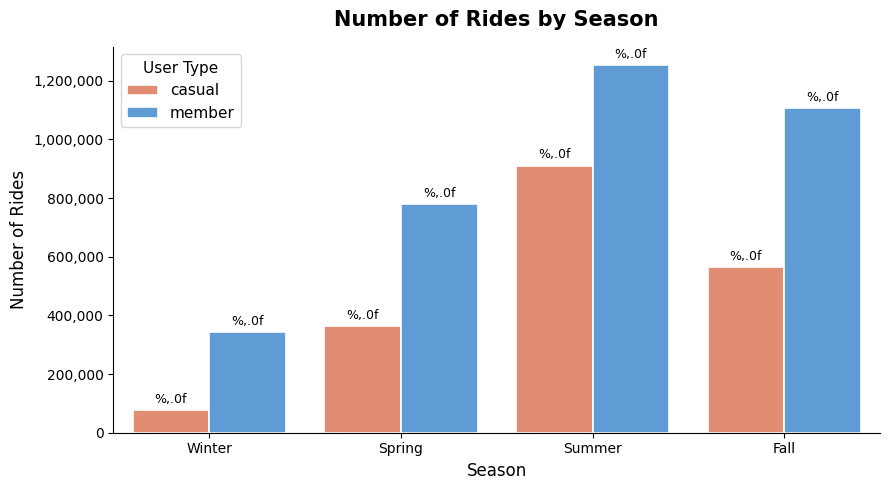

In [104]:
# Number of rides by season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall',  10: 'Fall',  11: 'Fall'
}
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

all_trips['season'] = all_trips['month_num'].map(season_map)

rides_by_season = (
    all_trips
    .groupby(['user_type', 'season'])['ride_id']
    .count()
    .reset_index()
)
rides_by_season['season'] = pd.Categorical(rides_by_season['season'], categories=season_order, ordered=True)
rides_by_season = rides_by_season.sort_values('season')

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=rides_by_season,
    x='season', y='ride_id',
    hue='user_type',
    palette={'casual': '#F4845F', 'member': '#4C9BE8'},
    edgecolor='white', linewidth=1.2,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%,.0f', fontsize=9, padding=3)

ax.set_title('Number of Rides by Season', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.legend(title='User Type', fontsize=11, title_fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


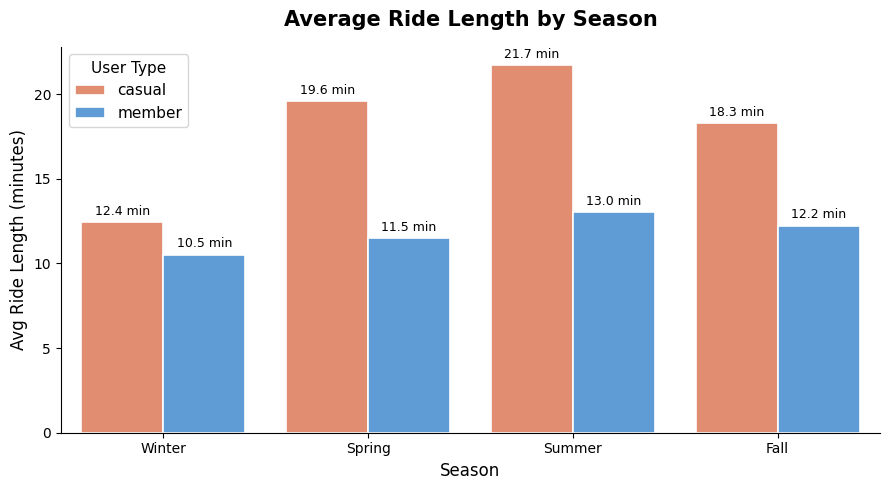

In [105]:
# Average ride length (minutes) by season
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

avg_length_season = (
    all_trips
    .groupby(['user_type', 'season'])['ride_length_m']
    .mean()
    .reset_index()
)
avg_length_season['season'] = pd.Categorical(avg_length_season['season'], categories=season_order, ordered=True)
avg_length_season = avg_length_season.sort_values('season')

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=avg_length_season,
    x='season', y='ride_length_m',
    hue='user_type',
    palette={'casual': '#F4845F', 'member': '#4C9BE8'},
    edgecolor='white', linewidth=1.2,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f min', fontsize=9, padding=3)

ax.set_title('Average Ride Length by Season', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Avg Ride Length (minutes)', fontsize=12)
ax.legend(title='User Type', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


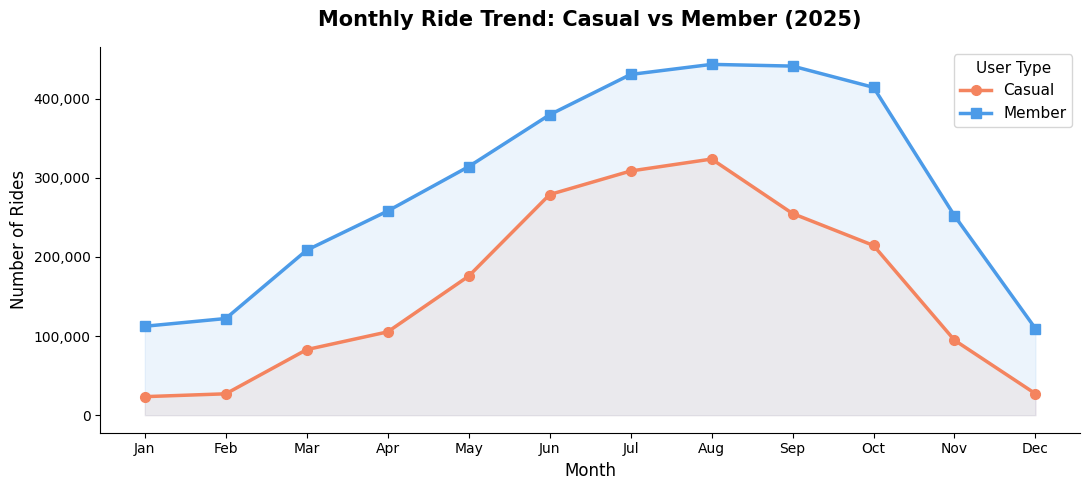

In [106]:
# Monthly ride trend - line chart
month_order = list(range(1, 13))
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

rides_by_month = (
    all_trips
    .groupby(['user_type', 'month_num'])['ride_id']
    .count()
    .reset_index()
)
rides_by_month['month_name'] = rides_by_month['month_num'].map(month_names)
rides_by_month['month_name'] = pd.Categorical(rides_by_month['month_name'],
                                               categories=list(month_names.values()), ordered=True)

fig, ax = plt.subplots(figsize=(11, 5))

for user, color, marker in [('casual', '#F4845F', 'o'), ('member', '#4C9BE8', 's')]:
    data = rides_by_month[rides_by_month['user_type'] == user].sort_values('month_num')
    ax.plot(data['month_name'], data['ride_id'],
            label=user.capitalize(), color=color,
            marker=marker, linewidth=2.5, markersize=7)
    ax.fill_between(data['month_name'], data['ride_id'], alpha=0.1, color=color)

ax.set_title('Monthly Ride Trend: Casual vs Member (2025)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='User Type', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


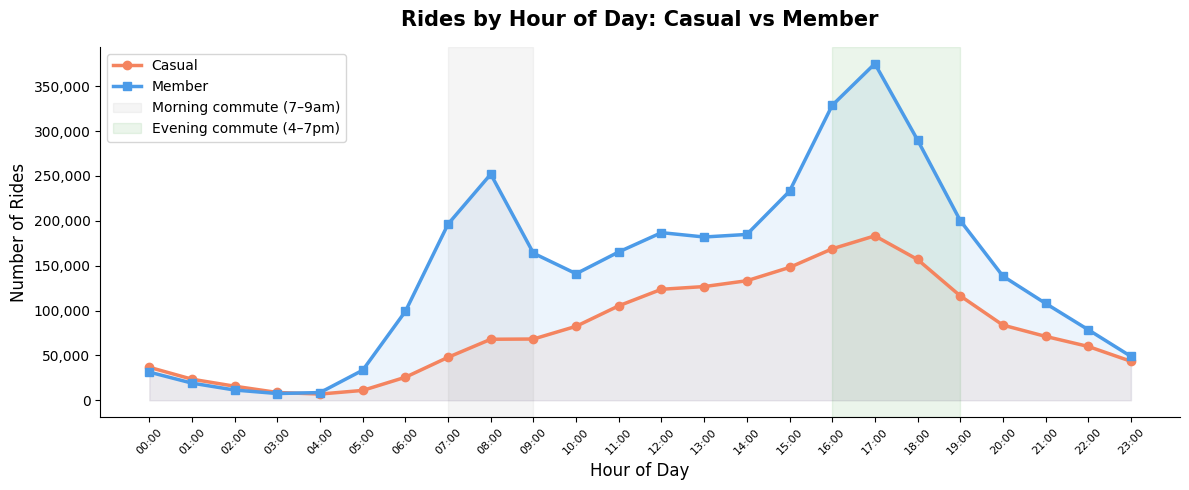

In [107]:
# Rides by hour of day
all_trips['hour'] = all_trips['started_at'].dt.hour

rides_by_hour = (
    all_trips
    .groupby(['user_type', 'hour'])['ride_id']
    .count()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for user, color, marker in [('casual', '#F4845F', 'o'), ('member', '#4C9BE8', 's')]:
    data = rides_by_hour[rides_by_hour['user_type'] == user].sort_values('hour')
    ax.plot(data['hour'], data['ride_id'],
            label=user.capitalize(), color=color,
            marker=marker, linewidth=2.5, markersize=6)
    ax.fill_between(data['hour'], data['ride_id'], alpha=0.1, color=color)

# Mark commute hours
ax.axvspan(7, 9, alpha=0.08, color='gray', label='Morning commute (7–9am)')
ax.axvspan(16, 19, alpha=0.08, color='green', label='Evening commute (4–7pm)')

ax.set_title('Rides by Hour of Day: Casual vs Member', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


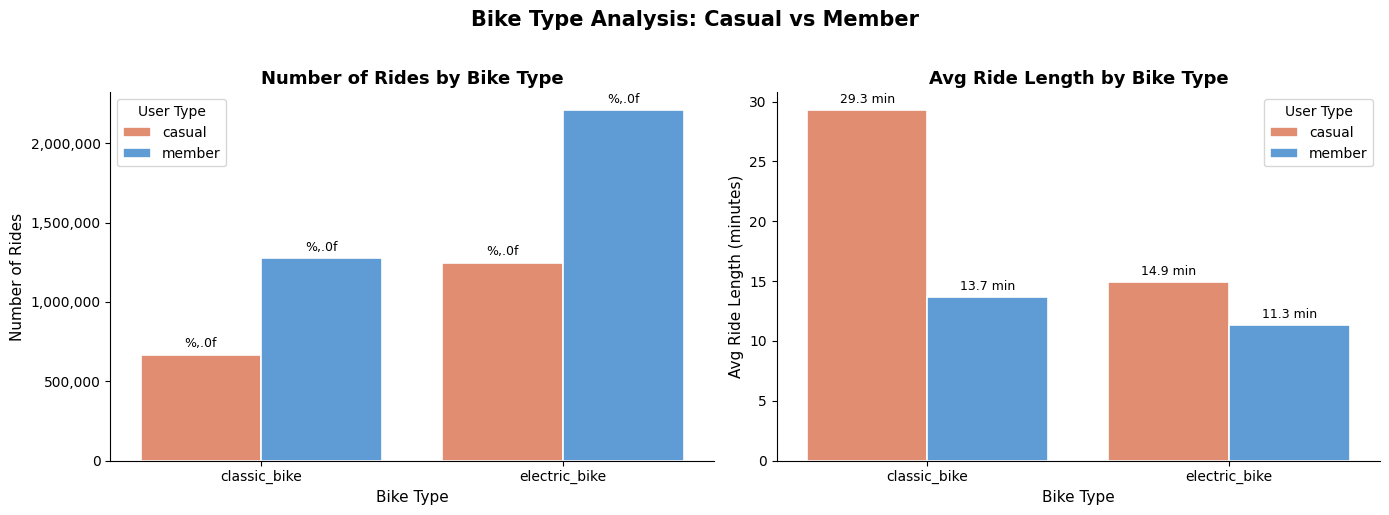

In [108]:
# Bike type deep dive: count + avg ride length by user_type x bike_type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Number of rides by bike type ──────────────────────────────────────
rides_by_bike = (
    all_trips
    .groupby(['user_type', 'bike_type'])['ride_id']
    .count()
    .reset_index()
    .rename(columns={'ride_id': 'ride_count'})
)

sns.barplot(data=rides_by_bike, x='bike_type', y='ride_count',
            hue='user_type',
            palette={'casual': '#F4845F', 'member': '#4C9BE8'},
            edgecolor='white', linewidth=1.2, ax=axes[0])

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%,.0f', fontsize=9, padding=3)

axes[0].set_title('Number of Rides by Bike Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bike Type', fontsize=11)
axes[0].set_ylabel('Number of Rides', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(title='User Type', fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Right: Avg ride length by bike type ─────────────────────────────────────
avg_by_bike = (
    all_trips
    .groupby(['user_type', 'bike_type'])['ride_length_m']
    .mean()
    .reset_index()
    .rename(columns={'ride_length_m': 'avg_minutes'})
)

sns.barplot(data=avg_by_bike, x='bike_type', y='avg_minutes',
            hue='user_type',
            palette={'casual': '#F4845F', 'member': '#4C9BE8'},
            edgecolor='white', linewidth=1.2, ax=axes[1])

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f min', fontsize=9, padding=3)

axes[1].set_title('Avg Ride Length by Bike Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Bike Type', fontsize=11)
axes[1].set_ylabel('Avg Ride Length (minutes)', fontsize=11)
axes[1].legend(title='User Type', fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Bike Type Analysis: Casual vs Member', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


/var/folders/sz/h4_jk39d2fj9818k_zlg891r0000gn/T/ipykernel_63812/3505023235.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Casual', 'Member'], fontsize=12)


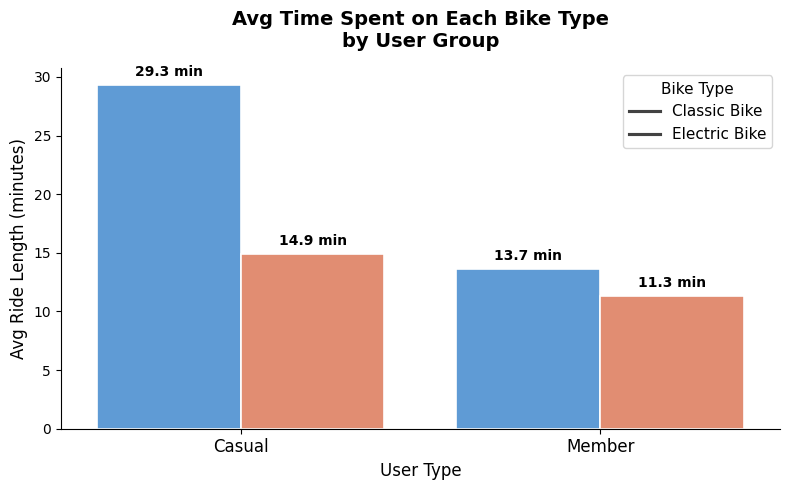

In [109]:
# Average ride length by user_type x bike_type
avg_by_bike = (
    all_trips
    .groupby(['user_type', 'bike_type'])['ride_length_m']
    .mean()
    .reset_index()
    .rename(columns={'ride_length_m': 'avg_minutes'})
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=avg_by_bike,
    x='user_type', y='avg_minutes',
    hue='bike_type',
    palette={'classic_bike': '#4C9BE8', 'electric_bike': '#F4845F'},
    edgecolor='white', linewidth=1.2,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f min', fontsize=10, padding=4, fontweight='bold')

ax.set_title('Avg Time Spent on Each Bike Type\nby User Group', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('User Type', fontsize=12)
ax.set_ylabel('Avg Ride Length (minutes)', fontsize=12)
ax.set_xticklabels(['Casual', 'Member'], fontsize=12)
ax.legend(title='Bike Type', labels=['Classic Bike', 'Electric Bike'], fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [110]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              KEY FINDINGS — CYCLISTIC 2025                  ║
╚══════════════════════════════════════════════════════════════╝

1. RIDE VOLUME
   • Members account for the majority of total rides
   • Casual riders take fewer but significantly longer rides

2. DAY OF WEEK BEHAVIOR
   • Members peak on weekdays (Mon–Fri) → commuter pattern
   • Casuals peak on weekends (Sat–Sun) → leisure pattern
   • Casual rides are longer than member rides on every day of the week

3. TIME OF DAY
   • Members show sharp spikes at 8am and 5pm → work commute
   • Casuals build gradually, peaking between 2pm–5pm → recreational use

4. SEASONAL TRENDS
   • Both groups peak in Summer and drop in Winter
   • Casuals drop far more steeply in Winter → fair-weather riders
   • Even in Winter, casuals still ride longer than members on average

5. BIKE TYPE
   • Both groups use classic and electric bikes
   • Casuals spend more time on classic bikes (leisure, sightseeing)
   • Electric bikes are used for shorter trips across both groups
""")



╔══════════════════════════════════════════════════════════════╗
║              KEY FINDINGS — CYCLISTIC 2025                  ║
╚══════════════════════════════════════════════════════════════╝

1. RIDE VOLUME
   • Members account for the majority of total rides
   • Casual riders take fewer but significantly longer rides

2. DAY OF WEEK BEHAVIOR
   • Members peak on weekdays (Mon–Fri) → commuter pattern
   • Casuals peak on weekends (Sat–Sun) → leisure pattern
   • Casual rides are longer than member rides on every day of the week

3. TIME OF DAY
   • Members show sharp spikes at 8am and 5pm → work commute
   • Casuals build gradually, peaking between 2pm–5pm → recreational use

4. SEASONAL TRENDS
   • Both groups peak in Summer and drop in Winter
   • Casuals drop far more steeply in Winter → fair-weather riders
   • Even in Winter, casuals still ride longer than members on average

5. BIKE TYPE
   • Both groups use classic and electric bikes
   • Casuals spend more time on classic 

In [111]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         TOP 3 RECOMMENDATIONS FOR CYCLISTIC MARKETING       ║
╚══════════════════════════════════════════════════════════════╝

RECOMMENDATION 1: Launch a Weekend Membership Tier
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Casuals ride most on weekends and for longer durations.
A discounted weekend-only membership would directly match
their existing behavior and lower the barrier to converting.
→ Target: Casual riders active on Sat–Sun
→ Message: "You already ride on weekends — make it cheaper."

RECOMMENDATION 2: Summer Conversion Campaign
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Casual ridership peaks in Summer (Jun–Aug). This is the
highest-intent window to convert them. A limited-time
Summer membership offer (May–June) can capture riders
before they hit their peak usage.
→ Target: Casual riders in Spring/early Summer
→ Message: "Ride all Summer for less — join before June."

RECOMMENDATION 3: Promote Commuter Benefits to Casual Riders
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Casuals currently don't use bikes for commuting (no 8am/5pm
spike). Showing them how membership pays off for daily
commutes — through cost-per-ride comparisons and health
benefits — can expand their usage from weekend-only to
weekday commutes, increasing the value of membership.
→ Target: Casual riders near high-traffic commuter stations
→ Message: "Save money. Skip traffic. Ride to work."
""")



╔══════════════════════════════════════════════════════════════╗
║         TOP 3 RECOMMENDATIONS FOR CYCLISTIC MARKETING       ║
╚══════════════════════════════════════════════════════════════╝

RECOMMENDATION 1: Launch a Weekend Membership Tier
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Casuals ride most on weekends and for longer durations.
A discounted weekend-only membership would directly match
their existing behavior and lower the barrier to converting.
→ Target: Casual riders active on Sat–Sun
→ Message: "You already ride on weekends — make it cheaper."

RECOMMENDATION 2: Summer Conversion Campaign
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Casual ridership peaks in Summer (Jun–Aug). This is the
highest-intent window to convert them. A limited-time
Summer membership offer (May–June) can capture riders
before they hit their peak usage.
→ Target: Casual riders in Spring/early Summer
→ Message: "Ride all Summer for less — join before June."

RECOMMENDATION 3: Promote Comm

In [78]:
# Save the merged DataFrame (with your new columns) to a CSV file on your computer:
print("Saving all_trips to 'combined_divvy_tripdata_2025.csv'...")
all_trips.to_csv("combined_divvy_tripdata_2025.csv", index=False)
print("Done! You will now see 'combined_divvy_tripdata_2025.csv' in your folder.")



Saving all_trips to 'combined_divvy_tripdata_2025.csv'...
Done! You will now see 'combined_divvy_tripdata_2025.csv' in your folder.
